# Identifying Obstacles to Equitable Flood Mitigation Funding

Julian Plough (University of North Carolina)  
Miyuki Hino [](https://orcid.org/0000-0001-9369-5769) (University of North Carolina at Chapel Hill, University of North Carolina)  
Antonia Sebastian [](https://orcid.org/0000-0002-4309-2561) (University of North Carolina at Chapel Hill, University of North Carolina)  
Helena Garcia [](https://orcid.org/0009-0008-3189-1658) (University of North Carolina)  
Russell Blessing [](https://orcid.org/0000-0003-4973-4032) (University of North Carolina at Chapel Hill)  
June 23, 2026

Federal flood mitigation funding in the United States flows to homeowners through a multi-stage application process administered by local governments. Identifying who is left out has been constrained by data: prior studies observe only who receives funding, not who is eligible or who applies. We construct a novel parcel-scale dataset linking flood exposure across 78 events from 1996 to 2020 with FEMA Hazard Mitigation Assistance applications and funding outcomes for 3.14 million residential properties in eastern North Carolina. Of 202,623 flood-exposed properties, 65.6% sit in jurisdictions with at least one HMA application, yet only 5,746 (2.8%) themselves apply, and 3,432 (59.7%) of those applications are funded. Repeat-flooded properties apply at roughly twice the rate of once-flooded properties but are funded at similar rates, indicating the application bottleneck is not resolved by greater flood exposure. Funded properties are concentrated in lower-value, less-white neighborhoods than the broader flood-exposed population, but within those neighborhoods they are typical rather than the cheapest homes, indicating that selection operates between neighborhoods rather than within them. Increasing application rates among flooded households is the largest leverage point our data identify for expanding access to federal mitigation assistance.

In [ ]:
library(readr)
library(dplyr)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

# Introduction

Flooding is the most costly natural hazard in the United States, and climate change is projected to intensify both its frequency and its financial burden \[@noaanationalcentersforenvironmentalinformationUSBillionDollarWeather2024\]. An estimated 41 million people live within the 1% flood hazard area, and the populations most exposed are disproportionately low-income, Black, and Native American \[@tateFloodExposureSocial2021\]. In response to mounting losses, federal investment in flood risk reduction has grown substantially, averaging over \$1.2 billion per year over the last decade. Yet growing evidence suggests this investment is not reaching those who need it most. Nationwide analyses find that wealthier and whiter counties have secured more federal mitigation funding, while racially and economically marginalized communities have received comparatively less \[@machManagedRetreatVoluntary2019; @elliottRacialInequitiesFederal2020a; @loughranUnequalRetreatsHow2022\]. Several mechanisms have been proposed to explain this pattern: federal cost-benefit analysis requirements that systematically favor high-value properties, limited local government capacity to administer grants, and lack of household awareness about available funding. These analyses, however, have observed only who receives funding, not who is eligible or who applies. As a result, it remains unclear where in the process inequities first emerge and which interventions would most effectively improve access.

Here, we combine novel datasets spanning over two decades of flood exposure, grant applications, and funding allocations in North Carolina to examine the full flooded-to-funded pipeline (@fig-funding-pipeline). Flood exposure is derived from a random forest model trained on address-level National Flood Insurance Program (NFIP) records, producing inundation footprints for 78 damaging events between 1996 and 2020 \[@garciaReconstructingRepetitiveFlood2025\]. We link these exposure records to property-level application and funding data for FEMA Hazard Mitigation Assistance (HMA) grant programs, provided by the North Carolina Department of Public Safety. Together, these datasets allow us to track individual properties across four stages (flooded, in an applying community, applied, and funded) and to examine how the composition of properties shifts in terms of flood exposure history, property value, and neighborhood racial demographics at each transition. This is the first analysis to follow properties from flood exposure through to mitigation funding outcome at the property level, making it possible to distinguish between households applying and not being selected and those that never enter the applicant pool at all.

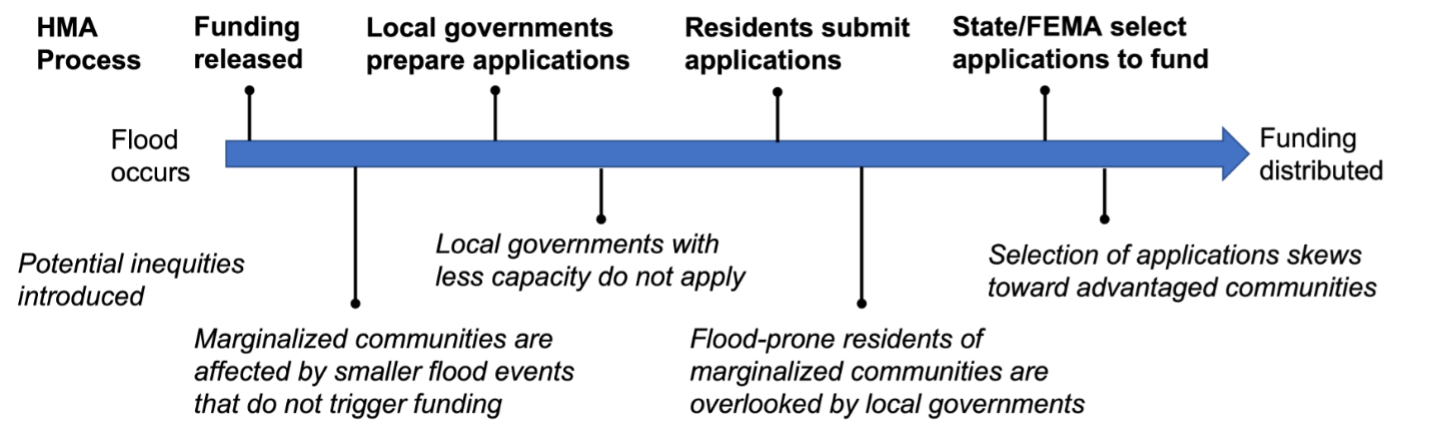{#fig-funding-pipeline }

## Access to federal funding for climate resilience

The federal government is the primary source of public assistance for disaster risk mitigation, post-disaster relief, and long-term recovery in the United States. Many federal agencies contribute to these efforts, including the US Army Corps of Engineers (which leads large-scale flood-control infrastructure), the Department of Housing and Urban Development (which administers Community Development Block Grant Disaster Recovery funds), the National Oceanic and Atmospheric Administration, and the Environmental Protection Agency. We focus our analysis on the Federal Emergency Management Agency (FEMA), which leads disaster response and administers the nation’s largest property-scale risk mitigation programs, including the Hazard Mitigation Grant Program (HMGP), Flood Mitigation Assistance (FMA), and Building Resilient Infrastructure and Communities (BRIC). FEMA made over \$1.6 billion available through BRIC and FMA alone in FY2024, with demand for these competitive funds regularly exceeding the available pool.

Concerns about equitable access to FEMA assistance in the aftermath of disasters have been extensively documented. Following presidential disaster declarations, FEMA’s Individuals and Households Program (IHP) provides up to approximately \$44,000 per household for temporary housing, property repair, unemployment assistance, and other immediate needs. Racial and income disparities in IHP access have been observed across a wide range of events, including the 1994 Northridge earthquake \[@bolinNorthridgeEarthquakeCommunitybased1998\], Hurricane Katrina \[@kamelSocialMarginalisationFederal2012\], Hurricane Dolly in South Texas \[@riveraProceduralVulnerabilityIts2022\], and the 2017 Thomas Fire \[@mendezInvisibleVictimsDisaster2020\]. More broadly, studies find that social vulnerability is inversely associated with access to federal disaster recovery funds even after accounting for the extent of damage \[@emrichAssessingDistributiveInequities2022; @drakesSocialVulnerabilityShortTerm2021; @wilsonFloodRecoveryOutcomes2021; @bentoRaciallyUnequalImpacts2022\].

Similar concerns have emerged around FEMA’s risk mitigation programs, which fund long-term adaptation rather than immediate recovery. Typical Hazard Mitigation Assistance (HMA) projects include home elevations, property buyouts, and community-scale infrastructure; since 2020, the Building Resilient Infrastructure and Communities (BRIC) program has expanded community-wide project funding. Among property-scale programs, buyouts have received the most scrutiny. In a buyout, homeowners sell flood-prone properties to local governments, which demolish structures and restore the land to open space. Initiated in 1985 and now totaling over 43,000 completed transactions nationally, the buyout program has shifted from its rural origins into an increasingly urban policy \[@machManagedRetreatVoluntary2019\]. Its geographic distribution is deeply uneven: states with the highest cumulative flood damages (Florida, Louisiana, Mississippi) rank among the lowest for buyout deployment, while activity concentrates in wealthier, denser counties with greater administrative capacity \[@machManagedRetreatVoluntary2019\]. Within those counties, bought-out properties are concentrated in lower-income and more racially diverse neighborhoods, a pattern Mach et al. \[-@machManagedRetreatVoluntary2019\] describe as a “buyout paradox” in which government capacity governs access at the county scale while within-county selection follows a different logic \[@elliottRacialInequitiesFederal2020a; @loughranUnequalRetreatsHow2022\]. Home elevation funding exhibits a different pattern, flowing disproportionately toward high-income and predominantly white communities \[@frankFEMAHomeElevation2022\].

## Procedural challenges to accessing funding

While these structural barriers shape outcomes at a broad scale, the mechanisms that produce inequity operate at the level of specific program rules and local implementation practices. The HMA application process is lengthy and multi-layered. After a presidential disaster declaration releases funding, state and local governments identify eligible properties, assist homeowners in compiling required documentation (including cost-benefit analyses, insurance records, and title documentation), and submit project proposals. Local governments (“sub-applicants”) forward proposals to the state (“applicant”), which screens projects before submitting to FEMA for final review. The full process from disaster declaration to project closeout averages nearly six years \[@machManagedRetreatVoluntary2019\]. The federal government covers 75% of project costs; states, local governments, and in some cases homeowners are responsible for the remaining 25% non-federal match.

Inequities can arise at every stage. At the county level, administrative capacity is the primary bottleneck: governments with dedicated staff, prior grant experience, and stronger institutional networks are far more effective at developing and submitting competitive proposals \[@machManagedRetreatVoluntary2019; @junodEquitableInvestmentsResilience2021a\]. At the community level, outreach practices vary widely; some local governments proactively contact eligible residents and guide them through the application process, while others do little or nothing, effectively limiting access to only those homeowners already aware of the program. Providing the 25% non-federal cost share can also be a barrier. In some states, including North Carolina, the state government covers the matching share for HMGP buyout projects under disaster declarations \[@ncdpsHazardMitigationGrant2026\]. Where the state does not, the funding must come from local government budgets or individual homeowners, which can significantly constrain participation among cash-strapped jurisdictions and lower-income households.

At the household level, procedural requirements such as documentation, inspections, and legal title verification can impose substantial compliance burdens. While these requirements apply uniformly to applicants, the practical difficulty of meeting them is likely to vary systematically with household resources, mirroring documented patterns in IHP access \[@riveraProceduralVulnerabilityIts2022; @rakerStratifyingDisasterState2023\]. Finally, federal cost-benefit analysis (CBA) requirements may further filter the pool. CBA evaluates projects on a benefit-to-cost ratio in which avoided losses scale with property replacement value, leading to concerns that applications from lower-value properties could face systematic disadvantages in the benefit-to-cost ratio \[@tateFloodExposureSocial2021; @junodEquitableInvestmentsResilience2021a; @millerCostCostEffectivenessExpanding2023\]. However, project costs also scale with property characteristics, and CBA exemptions exist for substantially damaged structures below specified cost thresholds, so the net distributional effect of CBA on funding outcomes remains an open empirical question.

Our analysis uses novel address-level data on the application and funding process to examine how each of these stages shapes the distribution of who ultimately benefits. By tracking properties from flood event to funding outcome, we can assess not just who receives mitigation assistance, but where along the pipeline the losses occur, and for whom.

# Results

We track 3.14 million residential parcels across 78 counties in eastern North Carolina through four sequential stages of the federal Hazard Mitigation Assistance pipeline: **flooded** (intersection with any of 78 modeled flood-event footprints from 1996 through 2020), **in an applying community** (jurisdiction with at least one HMA application submitted during the study period), **applied** (parcel itself named on an HMA application), and **funded** (application ultimately awarded). Flood-exposure data come from a random-forest model of NFIP claims and policies-in-force \[@garciaReconstructingRepetitiveFlood2025\], application and funding records from the North Carolina Department of Public Safety, and neighborhood demographics from the 2013 American Community Survey at the block-group scale. Property values come from the CoreLogic database and are expressed as percentile ranks across the study-area sample. Detailed methods are described in the Materials and Methods section.

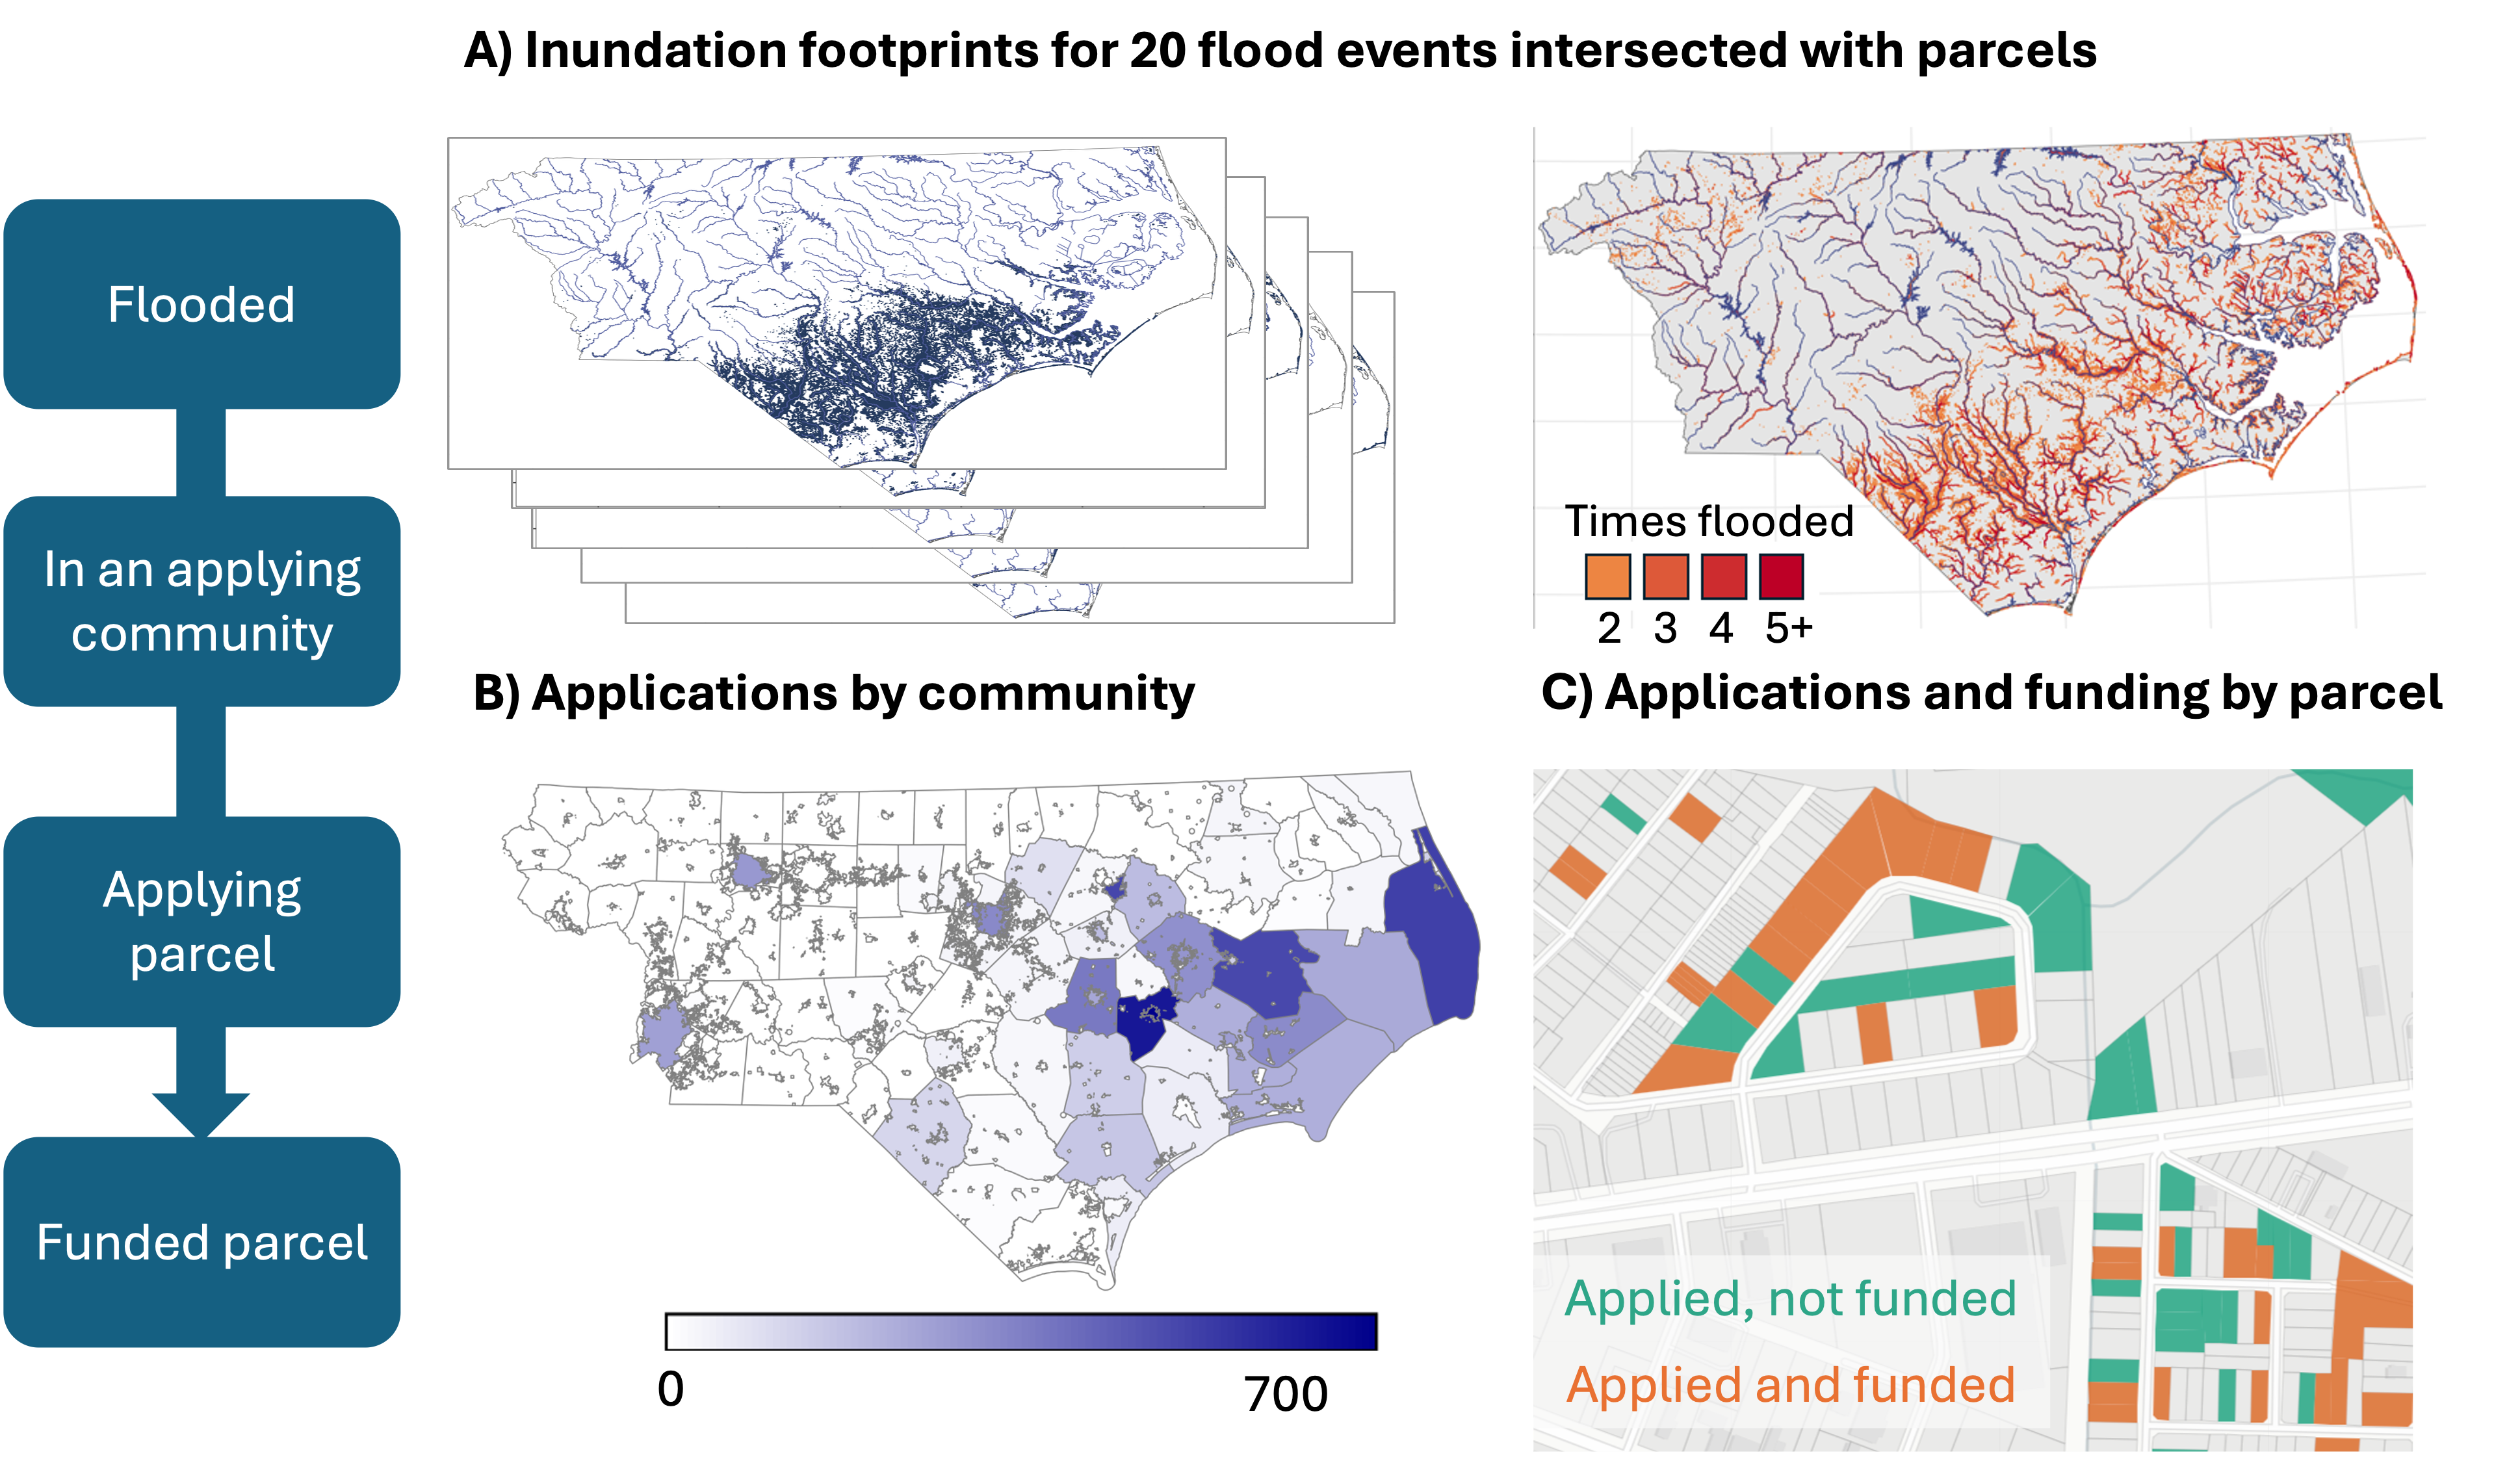{#fig-data fig-alt="Composite figure with a vertical pipeline flowchart on the left showing four sequential stages connected by arrows (Flooded, In an applying community, Applying parcel, Funded parcel) and four maps of eastern North Carolina showing the spatial distribution of parcels at each stage. Top-left map: stacked flooded parcel footprints across the study area, with dense clustering in eastern coastal and central regions. Top-right map: heatmap of repetitive flooding colored from orange to dark red by number of flood events affecting each location (2, 3, 4, or 5 or more events). Bottom-left map: choropleth of jurisdictions classified as applying communities shaded in blue, with denser participation in eastern counties. Bottom-right inset: zoomed neighborhood view of individual residential parcels colored teal for applied-but-not-funded and orange for applied-and-funded properties." width="100%"}

**Spatial distribution of properties across the flooded-to-funded pipeline.** Left: schematic of the four sequential pipeline stages tracked in our analysis. Top-left: flooded parcels (n = 202,623) across the 78-county study area, with stacked footprints from 78 modeled flood events between 1996 and 2020. Top-right: repetitive flooding intensity, with cells colored by the number of modeled flood events affecting each location (2, 3, 4, or 5+ events). Bottom-left: jurisdictions classified as applying communities (shaded by share of eligible parcels named on at least one HMA application). Bottom-right: representative neighborhood showing individual parcels named on HMA applications, distinguished by funding outcome (applied but not funded vs. applied and funded).

While most flooded properties are in communities that have applied for funding, very few properties submit applications themselves (@fig-funnel). Among all flooded properties (@fig-funnel, left panel), 65.6% are in jurisdictions where local government assisted with the submission of at least one HMA application. Only 2.8% of flooded properties are themselves named on an application, and 59.7% of those applications are funded.

Approximately 32.8% of flooded properties were exposed to more than one of the 78 modeled events (@fig-funnel, right panel). Repeat-flooded properties are more likely to be located in jurisdictions with at least one HMA application (81.1% versus 65.6% among all flooded properties) and themselves apply at roughly twice the rate of once-flooded properties (5.6% versus 2.8%). However, the share of applications that ultimately receive funding is essentially the same across the two groups (58.5% versus 59.7%), indicating that while greater flood exposure increases the likelihood of applying, it does not appear to influence selection outcomes among those who do apply.

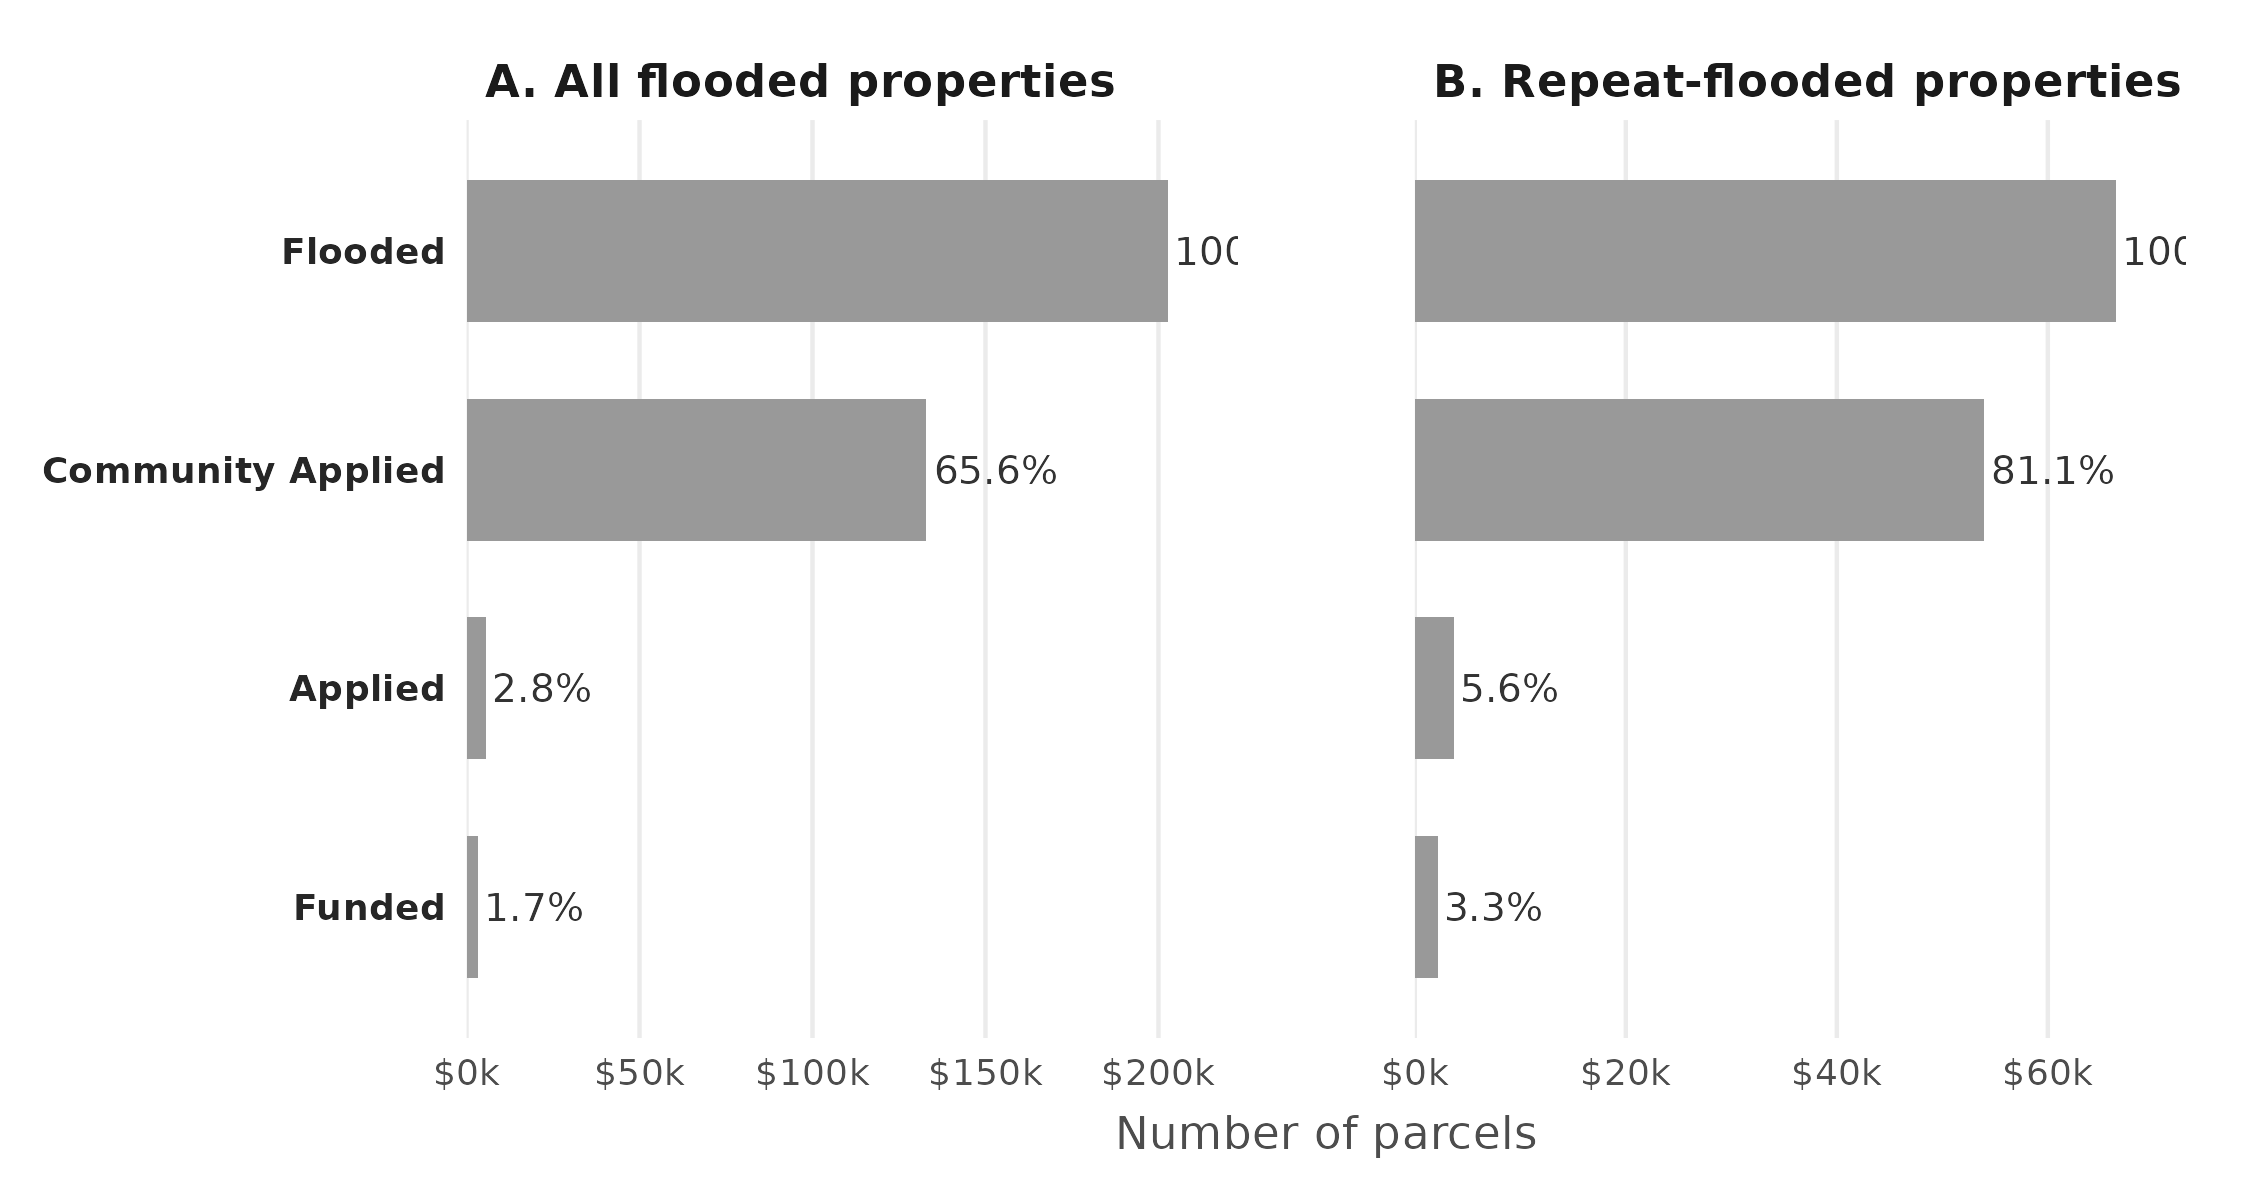{#fig-funnel fig-alt="Diagram showing parcel counts by the five pipeline stages — flooded, eligible, in an applying community, applied, funded" width="100%"}

**The application stage is the largest attrition point in the HMA pipeline: fewer than 3% of flooded properties ever submit an application.** Bars show the number of 1–4 family residential parcels at each of four pipeline stages: flooded in any of the 78 modeled events; in an applying community (jurisdiction with at least one HMA application during the study period); itself named on an HMA application; and ultimately funded. Panel A: all flood-exposed parcels (n = 202,623). Panel B: parcels exposed to flooding in more than one event (n = 66,443). Repeat-flooded properties apply at roughly twice the rate of once-flooded properties but are funded at similar rates.

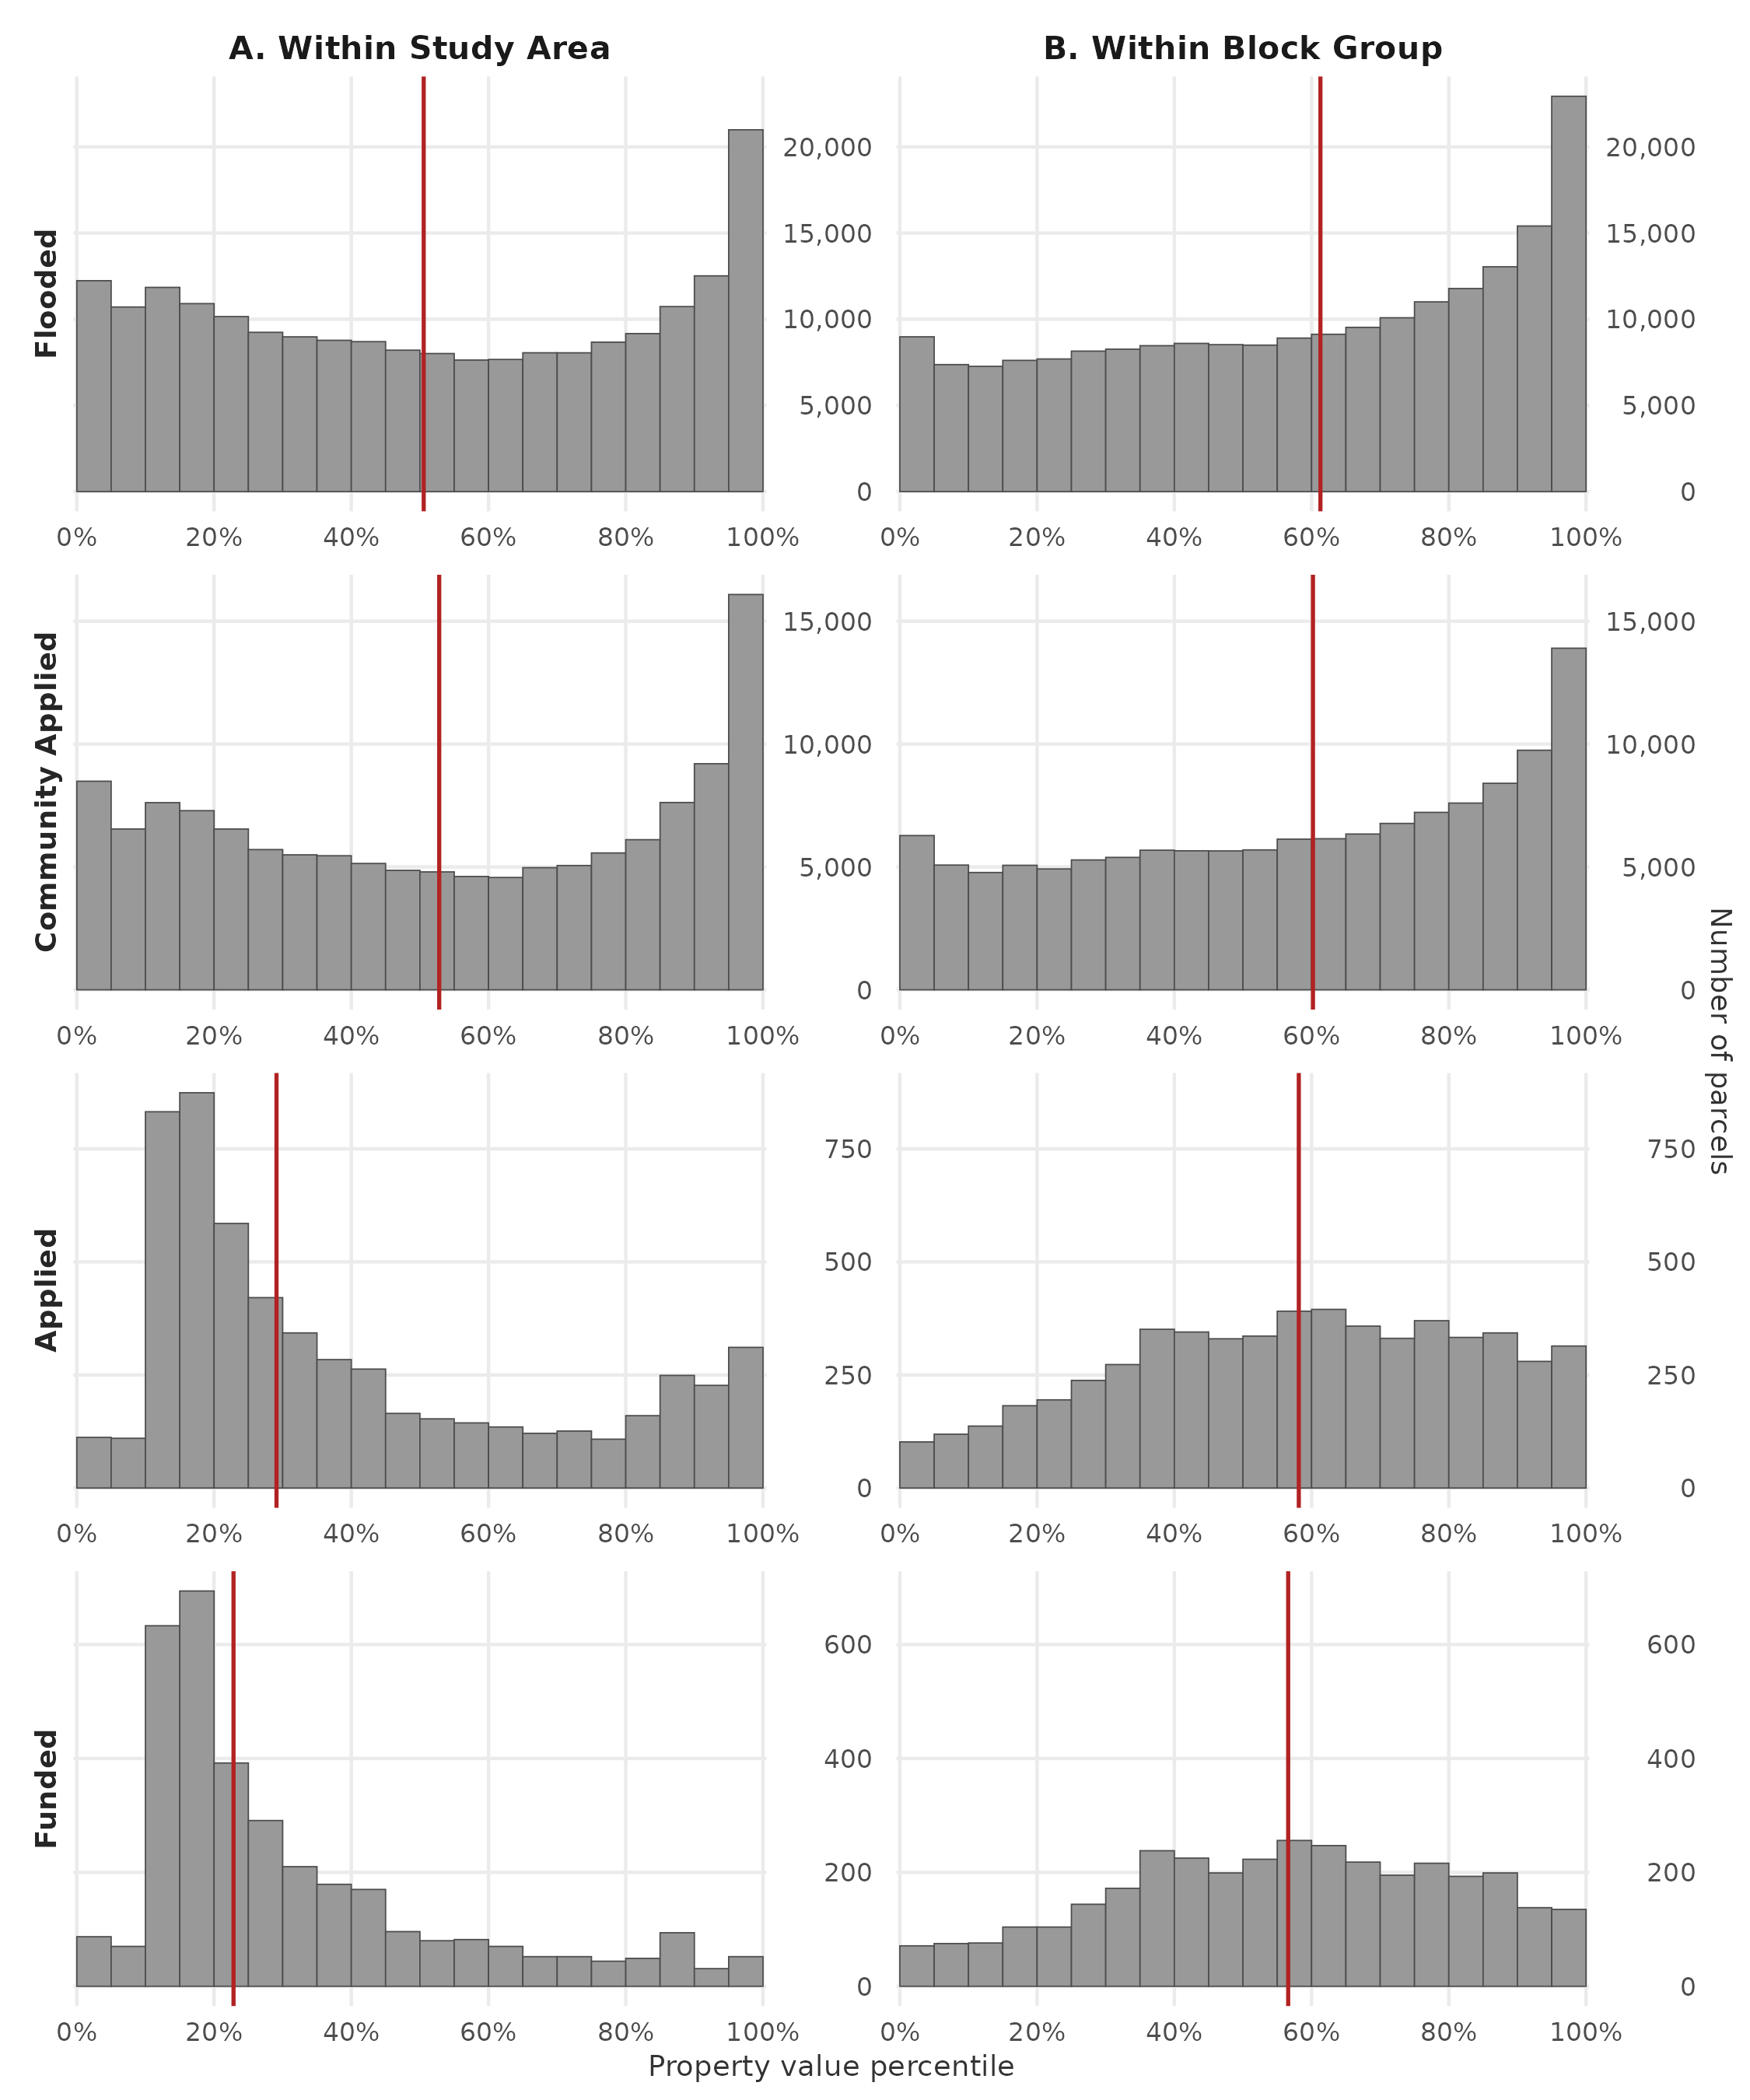{#fig-value fig-alt="Faceted histogram with two columns and four rows. Columns compare property value percentile rankings against the full study-area sample (left) versus within each parcel's own census block group (right). Rows correspond to four pipeline stages: Flooded, Community Applied, Applied, and Funded, top to bottom. Red vertical lines mark stage medians. Funded properties cluster at lower percentiles in the study-area panel but remain near the median in the block-group panel." width="100%"}

**Funded properties are within lower-value neighborhoods than the broader flood-exposed population, but are typical homes within those neighborhoods.** (A) Distribution of property values expressed as percentile ranks relative to the entire study-area sample. (B) Distribution expressed as percentile ranks within each property’s block group. Property values are from CoreLogic (2022 dollars); red vertical lines mark stage medians.

Property values shift substantially across pipeline stages, both relative to the broader study area and within each property’s own block group (@fig-value). Properties that flooded or that reside in communities with at least one HMA application have median values near the 51th–53th percentile of the study-area sample (Panel A). Properties that apply for funding drop to the 29th percentile, and those that are funded are even more affordable at the 23rd percentile. Panel B re-ranks each property against other parcels in its own block group, with all stages clustering near the 60th percentile (Flooded: 61st, Funded: 57th). The much larger spread in Panel A, where flooded properties are within the 51st percentile and funded properties at the 23rd, indicates that the property-value shift across pipeline stages is driven by selection between neighborhoods rather than within them. Funded properties are typical homes in lower-value neighborhoods, not the lowest-value homes in any given neighborhood.

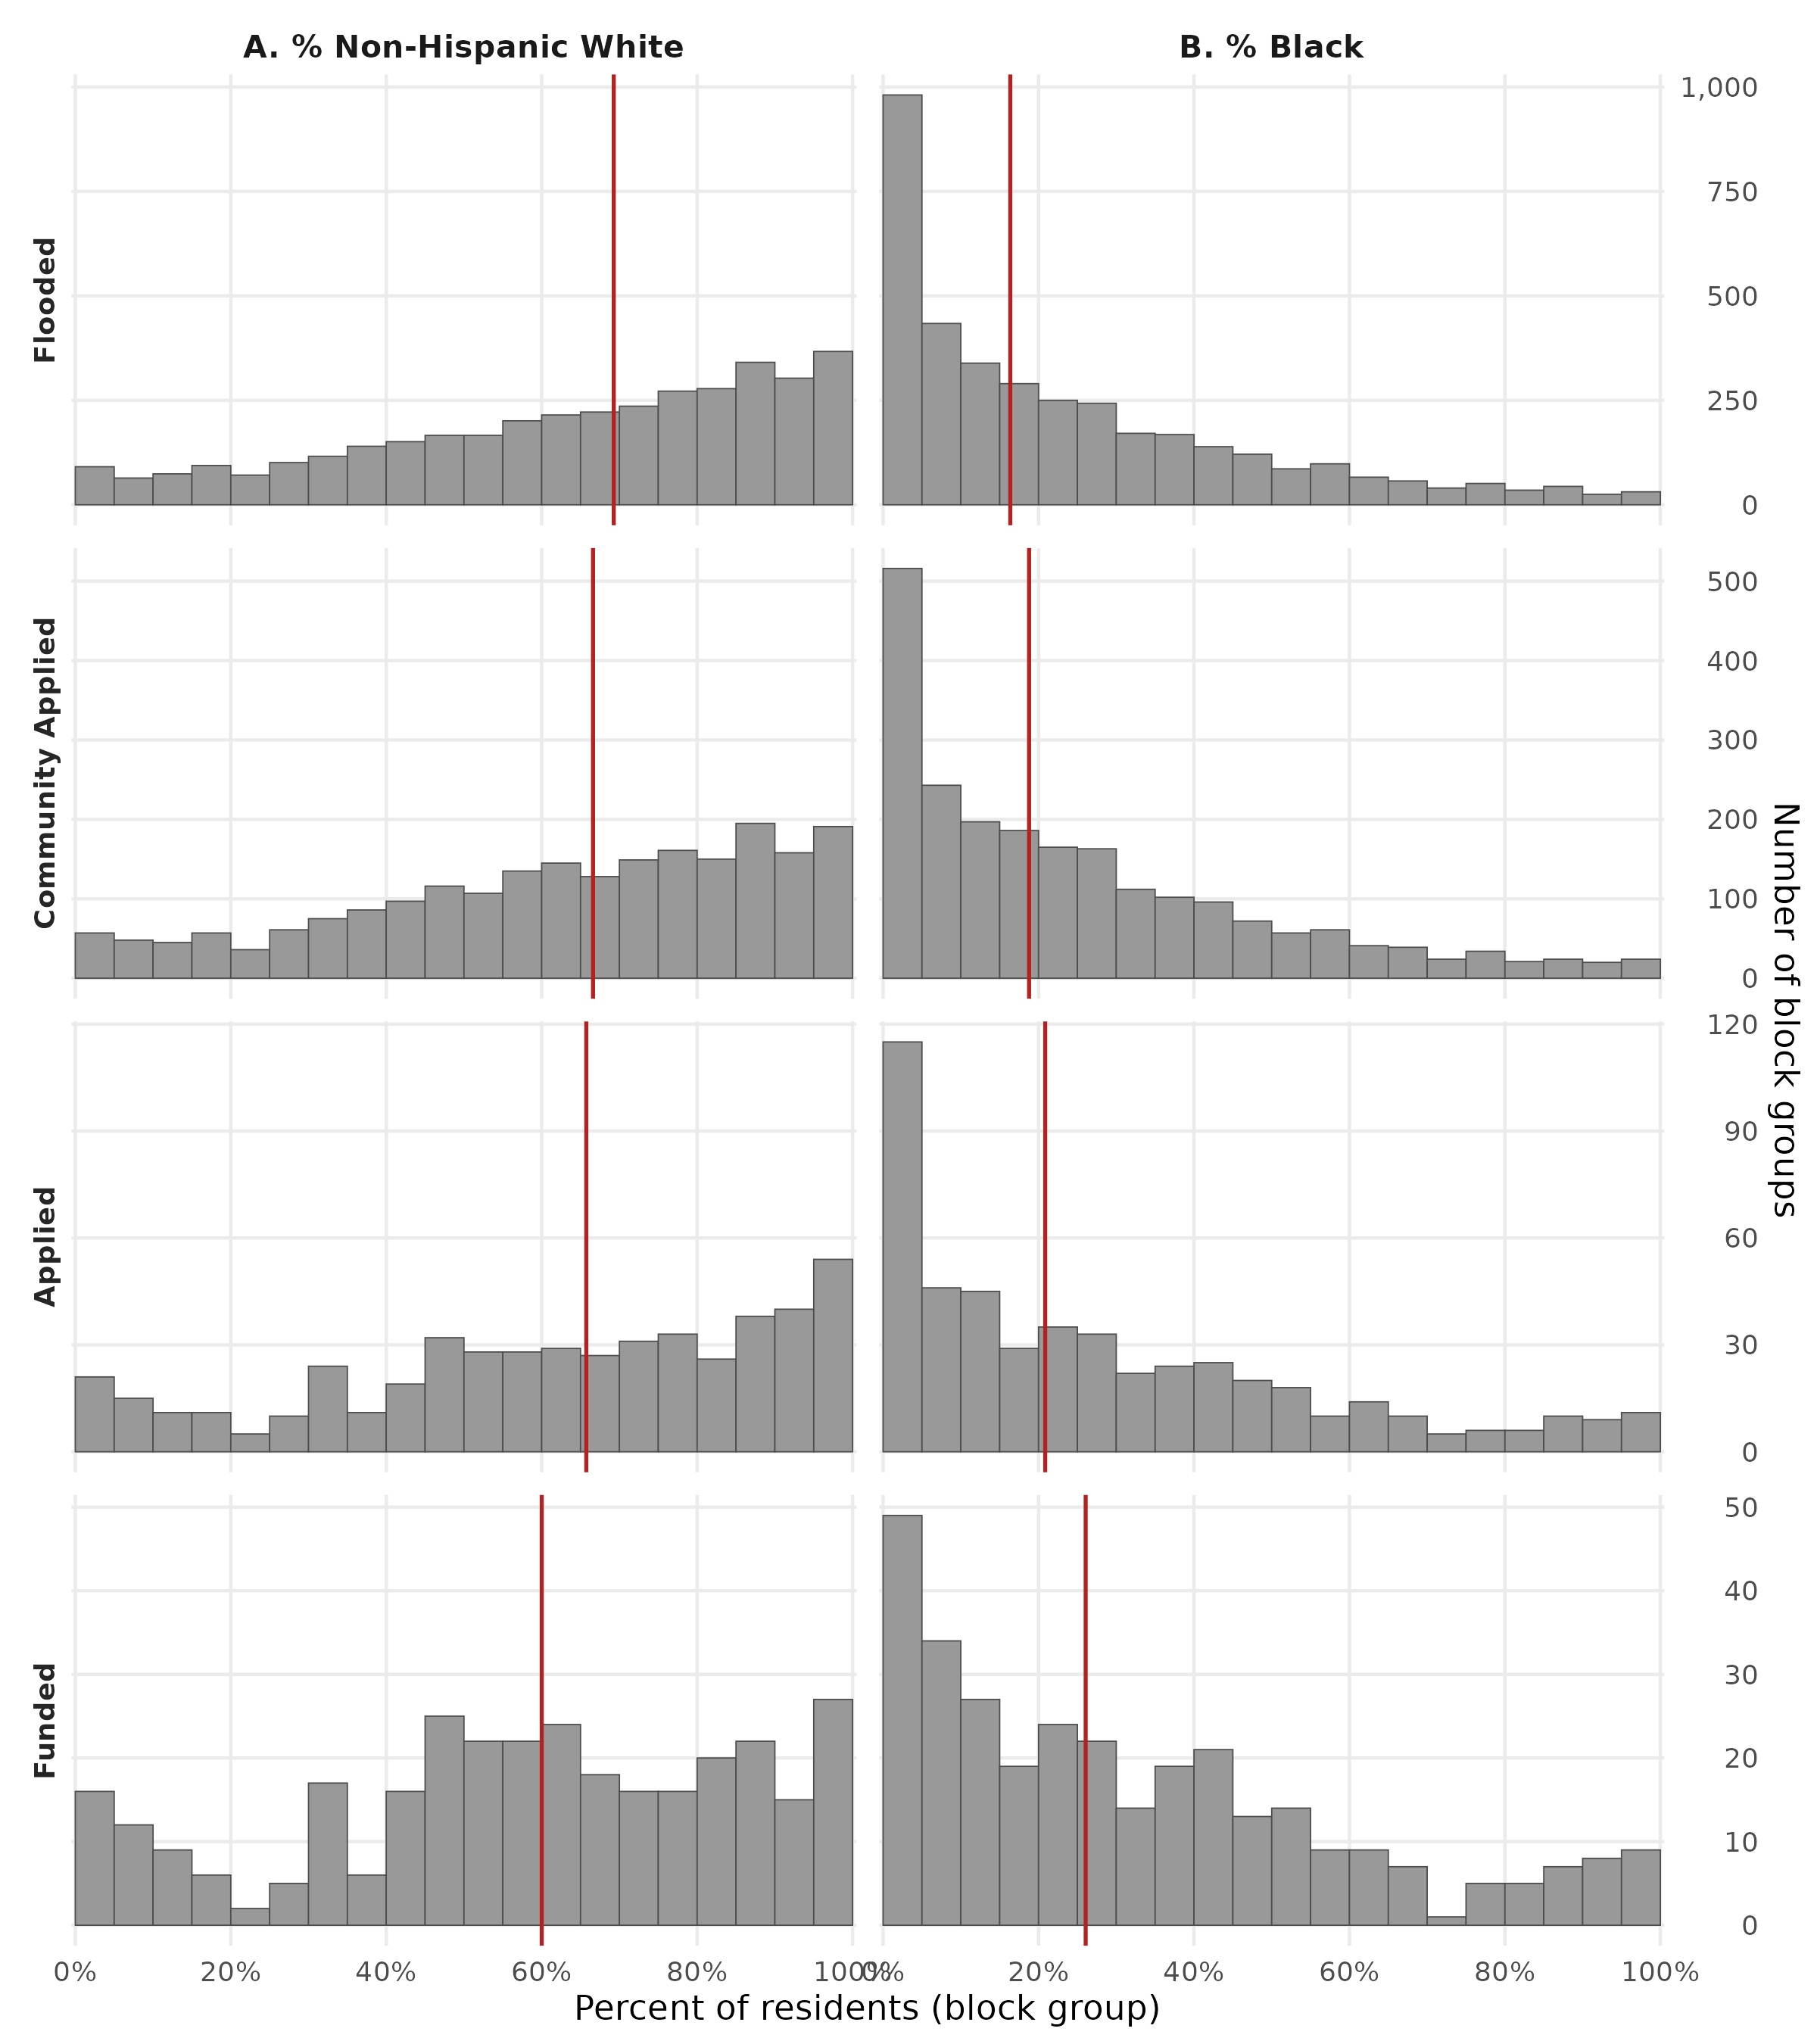{#fig-race fig-alt="Faceted histogram with two columns and four rows. Columns show the distribution of block-group percentages of non-Hispanic White residents (left) and Black residents (right). Rows correspond to four pipeline stages: Flooded, Community Applied, Applied, and Funded. Red vertical lines mark stage medians. The white-resident median shifts downward across stages while the Black-resident median shifts upward." width="100%"}

**Funded properties are concentrated in less-white, more-Black neighborhoods than the broader flood-exposed population.** (A) Percentage of non-Hispanic White residents. (B) Percentage of Black residents. One observation per block group containing ≥ 1 residential parcel reaching the stage; demographic data from the 2013 ACS 5-year estimates. Red vertical lines mark stage medians.

Properties applying for and receiving mitigation funding are located in block groups with lower shares of non-Hispanic White residents and correspondingly higher shares of Black residents than block groups at preceding pipeline stages (@fig-race). Two-sample Kolmogorov-Smirnov tests confirm that the distributions of block-group racial composition at the funded stage differ significantly from those at the flooded stage (NH White: D = 0.131, p \< 0.001; Black: D = 0.151, p \< 0.001). Median NH White share declines from 69.3% at the flooded stage to 60% at funded properties, with a near-symmetric rise in Black share from 16.4% to 26.1%.

The racial composition shift documented at the funded stage (@fig-race) is driven primarily by buyout activity rather than elevation activity (@fig-mit-type). Among funded parcels with a classified project type, buyouts outnumber elevations by approximately 4:1 (1,879 buyouts vs 415 elevations). Buyouts are located in block groups with substantially higher shares of Black residents than elevations (median 47% versus 35.7%; Kolmogorov-Smirnov D = 0.366, p \< 0.001), while property-value differences between mitigation types are more modest (median 20th versus 25.7th percentile; D = 0.141, p \< 0.001). The pattern holds in the repeat-flooded subset (D = 0.32 for racial composition), indicating that the buyout-elevation divergence is not driven by event-specific dynamics.

![**The racial composition shift at the funded stage is driven primarily by buyouts, while property-value differences between mitigation types are modest.** Distribution of (A) study-area property-value percentile rank and (B) block-group share of Black residents for funded parcels classified as buyouts (Acquisition, blue) and elevations (Elevation, red). Dashed vertical lines mark each group’s median. Funded parcels without a recorded project-type classification (approximately one-third of the funded set) are excluded. Statistical comparison: property value D = 0.141, % Black D = 0.366 (both p \< 0.001).](attachment:figures/fig5_mit_type.png){#fig-mit-type fig-alt="Two-panel histogram comparing distributions of property-value percentile (Panel A, left) and block-group percentage of Black residents (Panel B, right) for funded parcels classified as buyouts (blue) versus elevations (red). Buyout and elevation distributions overlap substantially in Panel A but diverge markedly in Panel B, with buyouts shifted toward higher Black-share block groups." width="100%"}

# Discussion

Our analysis identifies the application stage as the critical pinch point in the flooded-to-funded HMA pipeline. Of all flooded residential properties in eastern North Carolina, only 2.8% apply for funding, and of those, 59.7% receive an award. By tracking the full population of flooded properties rather than only those that received funding, we identify a substantial population of households who would benefit from mitigation assistance but do not appear in the applicant pool. This unrealized demand, to our knowledge not previously quantified at the property scale, suggests that interventions targeting the application stage may shift the composition of who ultimately receives funding more than further refinement of the selection criteria applied to existing applicants. Because HMA-funded mitigations have repeatedly been found to be cost-effective at the project level \[@multihazardmitigationcouncilNaturalHazardMitigation2017\], expanding the applicant pool among flooded households would translate to more cost-effective mitigation in aggregate, not merely a more competitive selection process among existing applicants.

Among the small fraction of properties that do receive funding, the composition shifts toward lower-value, less-white neighborhoods. Funded properties are within the 23th percentile of the study-area property-value distribution (compared to the 51th at the flooded stage) and in block groups with a median non-Hispanic white share of 60% (compared to 69.3%) and Black share of 26.1% (compared to 16.4%). The shift occurs primarily between neighborhoods rather than within them: within-block-group percentiles for funded properties differ only modestly from those at the flooded stage. This pattern aligns with prior county-scale evidence \[@machManagedRetreatVoluntary2019; @elliottRacialInequitiesFederal2020a\] and likely reflects the strong correlation between race and property value in eastern North Carolina, where less-white neighborhoods tend to also be lower-value.

Repeat-flooded properties apply at roughly twice the rate of once-flooded properties but are funded at similar rates. This pattern suggests that flood-exposure history influences application behavior more than selection outcomes, and points to an underused targeting lever for HMA prioritization. HMGP, which dominates HMA funding in our study area, becomes available event-by-event following presidential disaster declarations and weights damage from a single event heavily in the cost-benefit calculation. Mitigation programs that gave greater weight to a property’s cumulative flood history, rather than only the severity of a single damaging event, would more closely align selection with the population our data identifies as most likely to be affected again.

Decomposing the funded set by mitigation type reveals that the racial composition shift at the funded stage is driven primarily by buyout activity rather than elevation activity (@fig-mit-type). Buyouts dominate the funded record (approximately 4:1 over elevations among classified parcels) and concentrate in block groups with substantially higher shares of Black residents than elevations (KS D = 0.366, p \< 0.001). Property-value differences between mitigation types are more modest (D = 0.141), suggesting that the property-value shift across the pipeline reflects a neighborhood-scale selection process affecting both mitigation types similarly, while the racial composition shift reflects a buyout-specific dynamic. This pattern extends prior county-scale findings of demographic differences between buyout and elevation targeting \[@machManagedRetreatVoluntary2019; @elliottRacialInequitiesFederal2020a; @frankFEMAHomeElevation2022\] to the parcel scale within neighborhoods, and persists in the repeat-flooded subset (D = 0.32), suggesting it reflects structural differences in how buyouts and elevations are sited rather than event-specific dynamics.

Our cross-sectional data also let us rule out several candidate mechanisms for the equity patterns we observe. If the federal cost-benefit analysis (CBA) requirement were primarily driving selection toward higher-value properties, we would expect funded properties to be concentrated at higher property values; instead, we see the opposite. Because CBA is a federal rule applied uniformly across states, this pattern should generalize beyond North Carolina. The high community participation rate in our study area (65.6% of flooded properties are in jurisdictions with at least one HMA application) similarly argues against wholesale community-level non-participation as the binding constraint, though this likely differs in states without state-level cost-share absorption like North Carolina’s. We also see no evidence of applicant pools dominated by high-value properties, which would be consistent with local governments selectively recruiting wealthier households for application support. Together, these patterns are most consistent with a selection mechanism operating at the neighborhood scale that concentrates funding in lower-value, less-white communities; disentangling whether this reflects programmatic preferences for buyout siting, differential outreach, or other mechanisms is an important direction for future work.

Several methodological limitations apply. First, our flood-exposure data come from a reconstruction of 78 flood events in eastern North Carolina between 1996 and 2020 \[@garciaReconstructingRepetitiveFlood2025\]. The underlying models are conservative and likely underestimate the true population of flood-exposed properties. A sensitivity analysis dropping the seven events Garcia et al. flag for unusually high modeled-to-observed damage ratios produces materially identical headline findings: the funded population shifts by only 2.3% and median demographic compositions move by less than half a percentage point (Supplementary Materials). Second, our data on the timing of applications and mitigations is incomplete, so we do not distinguish between floods that occur before or after a property is funded for mitigation. This is particularly relevant for our repeat-flood analysis: properties that were elevated or bought out before a subsequent modeled flood event may appear in our data as repeat-flooded even though the structure may no longer have been exposed or may have been physically removed. Third, approximately one third of funded mitigation records in our data lack a project-type classification, so our buyout-versus-elevation comparison (Results section, @fig-mit-type) is restricted to the classified subset. The unclassified records may not be randomly distributed across mitigation types, and any systematic gap (for example, if smaller or older projects disproportionately lack documentation) could affect the magnitude of the buyout-elevation contrast we report. Fourth, our block-group demographic data come from the 2013 American Community Survey, which falls near the midpoint of the study window but does not capture demographic changes over the full 1996–2020 period. Finally, while we document more of the application process than past studies, there are still many aspects that we do not observe, such as how local governments approach (or fail to approach) flooded households about funding opportunities, procedural obstacles that may deter applications from interested households, and sources of non-governmental assistance.

A broader conceptual limitation concerns the interpretation of our findings. We document that federal mitigation funding flows to lower-value, less-white neighborhoods relative to the broader flood-exposed population. This pattern is consistent with mitigation reaching historically underserved communities, but we cannot determine from our data whether the mitigation outcomes themselves are equitable for participating households. Buyouts in particular involve household relocation, and prior research has raised concerns about whether buyout participation reflects informed preference or limited alternatives \[@machManagedRetreatVoluntary2019\]. Establishing whether the distribution of funding we observe represents equitable outcomes would require post-mitigation data on household well-being that we do not have. Our findings rule out some procedural drivers of inequity but do not by themselves demonstrate that the present distribution of funding meets a substantive standard of equity.

## Conclusions

Our paper is the first to follow individual residential properties from flood exposure through mitigation funding outcome at each significant stage, including the previously-unobservable application stage. The largest falloff in the pipeline is the application step, where the composition of properties that reach subsequent stages shifts toward lower-value properties and less-white neighborhoods, primarily through between-neighborhood selection rather than within-neighborhood selection. These results identify the application stage as the largest leverage point for expanding access to federal mitigation funding. At the same time, given that only 59.7% of applications receive funding, expanding the available funding pool is equally critical: federal mitigation assistance has the highest marginal benefit precisely for households without the financial capacity to fund flood mitigation independently. These findings arrive amid significant federal restructuring of hazard mitigation policy. The FEMA Review Council’s May 2026 final report recommended replacing HMGP with a state-managed Refined Risk Reduction Program that would prioritize repetitively flooded properties and acknowledged administrative burdens that may discourage applications from under-resourced communities \[@femaReviewCouncilFinal2026\], echoing concerns reinforced by the application-stage attrition we identify here. Our property-level evidence suggests that reforms focused on funding speed and federal priority-setting may not by themselves resolve the equity patterns we document without complementary attention to the upstream application bottleneck. Future research could extend this approach to community-scale infrastructure investments such as stormwater system upgrades and BRIC community projects, which may also reduce household-level flood risk through complementary pathways.

# Methods

We assemble over 20 years of data on flood exposure, applications for state and federal funding, and funding allocations. Flood exposure data are generated using a random forest model trained on address-level records of National Flood Insurance Program (NFIP) policies-in-force and claims filed from January 1996 through September 2020, obtained from FEMA Region IV \[@garciaReconstructingRepetitiveFlood2025\]. The model domain encompasses the entirety of the Neuse–Pamlico and Cape Fear watersheds and portions of the Pee Dee and Chowan–Roanoke watersheds that drain through eastern North Carolina, overlapping with 78 of North Carolina’s 100 counties. This measure indicates whether a parcel intersected the modeled footprint of an event but does not capture the severity of any individual exposure; some properties classified as flooded may have experienced relatively minor inundation. We link these flood exposure data to parcel geometries from the North Carolina OneMap database, attribute records from the CoreLogic property database, application and funding records from the North Carolina Department of Public Safety (NCDPS), and block-group demographic data from the American Community Survey (ACS).

We use this combined dataset to track residential properties through four sequential stages of the flood mitigation funding pipeline (@fig-overview): whether a property has flooded, whether its local government has applied for funding, whether the property itself is named on an application, and whether that application was funded. Eligibility for HMGP funding (defined as inundation during a presidentially-declared event in the property’s county) is applied as an analytical filter within these stages but not displayed separately in the figures. The framework allows us to identify, at each transition, which properties drop out and how the composition of the remaining pool shifts in terms of flood-exposure history, property value, and neighborhood racial composition.

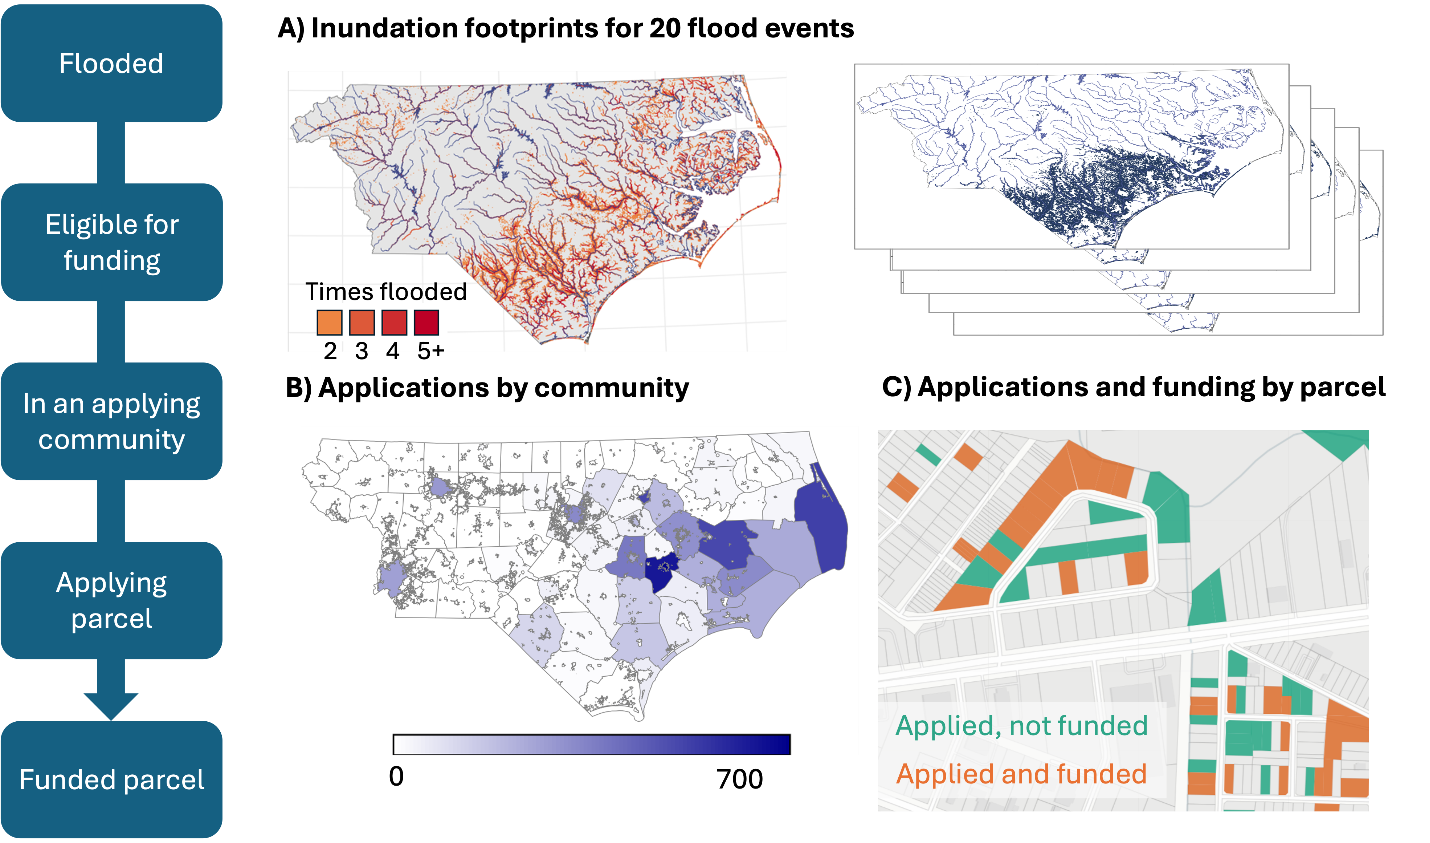{#fig-overview fig-alt="Diagram showing five pipeline stages — flooded, eligible, in an applying community, applied, funded — with the data source linked to each stage" width="100%"}

## Study area and unit of analysis

The base unit of analysis is the residential parcel. Parcel geometries are sourced from the North Carolina OneMap database, which aggregates county tax assessor records into a statewide spatial layer. Each parcel is linked to property-level attributes (land use code, structure characteristics, assessor value) drawn from the CoreLogic property database. Where parcel records and CoreLogic records share a common identifier we match directly; the remaining parcels are matched spatially, with address-string similarity used to break ties when more than one CoreLogic record is closest. We retain 1–4 family residential parcels and exclude commercial, industrial, agricultural, and most government-owned land uses. A small number of residential parcels are recorded in CoreLogic as currently vacant or government-owned. Because completed buyouts demolish the structure and transfer the parcel to public ownership, these post-buyout parcels appear in the present-day data with property values that reflect their post-mitigation rather than pre-mitigation state. To recover a pre-mitigation value for parcels that we have reason to believe were previously residential, we impute the property value as the mean assessor value of the five nearest non-vacant residential parcels. Parcels that are vacant for reasons unrelated to mitigation are excluded from the property-value analysis. The final analytic sample comprises 3,137,520 parcels.

## Flooded-to-funded pipeline stages

Flood exposure is constructed at the parcel level using inundation footprints generated by Garcia et al. \[-@garciaReconstructingRepetitiveFlood2025\] using a random-forest model trained on address-level NFIP policies-in-force and claims records for January 1996 through September 2020, obtained from FEMA Region IV, and produces 30 m × 30 m gridded inundation footprints for individual flood events. We retain the 78 events with the largest claim counts in the study area, which together account for 95% of all NFIP claims filed over the period \[@garciaReconstructingRepetitiveFlood2025\]. A parcel is classified as flooded if its geometry intersects the footprint of at least one of these 78 events. This property-resolved flood history serves as the reference set against which subsequent pipeline stages are measured, enabling the first parcel-level linkage between flood exposure and federal mitigation outcomes in the region.

Application and funding records cover two FEMA Hazard Mitigation Assistance (HMA) programs administered by NCDPS: the Hazard Mitigation Grant Program (HMGP), which becomes available following presidential disaster declarations (PDDs) issued event-by-event and county-by-county; and Flood Mitigation Assistance (FMA), which depends on a property’s NFIP claim and policy history rather than on a PDD. FMA encompasses the repetitive-loss pathways previously administered under the standalone Repetitive Flood Claims (RFC) and Severe Repetitive Loss (SRL) programs before their consolidation into FMA in FY2014. Of the 78 events in our flood-exposure dataset, 18 triggered PDDs covering at least one North Carolina county; these constitute the universe of disaster declarations from which HMGP funding could flow during our study period.

NCDPS provided address-level records of every project submitted for HMA funding under HMGP and FMA, along with the subset of those projects that were ultimately funded. Application records (n = 23,232) and funded mitigation records (n = 8,801) span 1996 through 2018, encompassing major North Carolina disaster events including Hurricanes Fran (1996), Floyd (1999), Isabel (2003), Irene (2011), Matthew (2016), and Florence (2018). Hurricane Floyd dominates the funded record, accounting for 58% of mitigations with a recorded disaster year.

The HMA application process is administered through local governments. Households cannot apply directly to FEMA: instead, a county or municipal government compiles project documentation (including the cost-benefit analysis, NFIP claim records, and deed and title records) and submits applications on behalf of interested homeowners, often with state-level coordination from NCDPS. Local governments differ substantially in their willingness and capacity to do this work \[@machManagedRetreatVoluntary2019; @junodEquitableInvestmentsResilience2021a\]. To capture this community-level filter, we assign every parcel to its containing municipality, or to its containing county where no municipality exists, and classify each jurisdiction by whether it submitted at least one HMA application during the study period. Within applying jurisdictions, we then geocode application and funding records back to OneMap parcels and classify each property as never applied, applied but not funded, or applied and funded.

## Pipeline analysis

Property values are taken from the most recent CoreLogic vintage and used at the parcel level. We express each property’s value as a percentile rank across all 1–4 family residential parcels in the study area, using relative rather than absolute property value as our primary property-value measure throughout the analysis. To complement the broad ranking, we also compute each property’s value as a percentile rank within its own census block group. This within-neighborhood percentile lets us test whether selection toward lower-value properties occurs within neighborhoods or primarily reflects selection toward lower-value neighborhoods.

Neighborhood-level race and income data are obtained at the census block-group scale and joined to each parcel based on its containing block group. We use the 2013 vintage of the American Community Survey because it falls near the midpoint of our 1996–2020 flood-exposure window. The 18 disaster declarations represented in our study area span this period, with the earliest being Hurricane Fran (1996) and the most recent being Hurricane Florence (2018). Block-group variables include the share of residents identifying as non-Hispanic white, the share identifying as non-Hispanic Black, and median household income. We aggregate parcel-level results to the block group when reporting demographic-composition shifts across pipeline stages.

The four-stage pipeline is a sequence of nested subsets: each stage is, by construction, a subset of the previous one. We characterize each stage in two ways. First, we count the number of parcels that survive into the stage and report stage-to-stage attrition rates for both once-flooded parcels and parcels that flooded two or more times (i.e., repeatedly flooded parcels). Our flood-exposure measure captures only the number of events a parcel intersected, not the severity (such as depth, duration, or damage) of any individual exposure. Second, we describe the distribution of property values (study area wide percentile rank) and block-group demographics at each stage, to identify where in the pipeline shifts in wealth and racial composition emerge.

This cross-sectional design intentionally treats the pipeline as a series of selection filters. By observing applications, funding, and flood exposure at the parcel level for every residential property in the study area, we identify the transitions at which inequities emerge, rather than inferring them from funded properties alone.

## Mitigation type classification

To examine whether the wealth and racial-composition shifts we observe at the funded stage differ between buyouts and elevations, we classify each funded mitigation record by project type. NCDPS records contain a `project_type` field that distinguishes acquisitions (which requires household relocation) from elevations (which preserves in-place residence). We classify parcels with at least one acquisition record as buyouts and parcels with at least one elevation record (and no Acquisition) as elevations. Approximately one third of funded parcels lack a project-type classification in the NCDPS records, and the comparison below is restricted to the classified subset of 2,294 parcels.

# References

# Acknowledgments

This material is based upon work supported by the U.S. Department of Homeland Security under Grant Award Number 2015-ST-061-ND0001-01, and by the National Oceanic and Atmospheric Administration (NOAA) Climate Program Office Regional Integrated Sciences and Assessments program \[NA21OAR4310312\]. We thank the North Carolina Department of Public Safety for providing application and funding records, and Helen Klass-Warch for her work on the mitigation and application data assignments. The views and conclusions contained herein are those of the authors and should not be interpreted as necessarily representing the official policies, either expressed or implied, of the U.S Department of Homeland Security or NOAA. NOAA had no role in the design or conduct of the study; data analysis or interpretation; preparation, review, or approval of the manuscript; or decision to submit the manuscript for publication.

# Supplementary Materials

![**Block-group median household income across the HMA pipeline.** Distribution of block-group median household income (2013 ACS 5-year estimates) for block groups containing at least one residential parcel reaching each pipeline stage. Panel A shows all flood-exposed parcels; Panel B is restricted to repeat-flooded parcels (those exposed to more than one of the 78 modeled events). Stages from top to bottom: Flooded, Community Applied, Applied, Funded. Red vertical lines mark stage medians. The x-axis is truncated at \$175,000 for readability.](attachment:figures/fig5a_income.png){#fig-si-income fig-alt="Eight-panel histogram in a four-row by two-column grid showing block-group median household income across four HMA pipeline stages (Flooded, Community Applied, Applied, Funded) for all flood-exposed properties (Panel A, left column) and repeat-flooded properties (Panel B, right column). X-axis ranges from 0 to 175,000 dollars; red vertical lines mark stage medians within each panel." width="100%"}

![**Block-group median home value across the HMA pipeline.** Distribution of block-group median home value for owner-occupied housing (2013 ACS 5-year estimates) for block groups containing at least one residential parcel reaching each pipeline stage. Panel A shows all flood-exposed parcels; Panel B is restricted to repeat-flooded parcels. Stages from top to bottom: Flooded, Community Applied, Applied, Funded. Red vertical lines mark stage medians. The x-axis is truncated at \$500,000 for readability.](attachment:figures/fig5b_home_value.png){#fig-si-homevalue fig-alt="Eight-panel histogram in a four-row by two-column grid showing block-group median home value across four HMA pipeline stages (Flooded, Community Applied, Applied, Funded) for all flood-exposed properties (Panel A, left column) and repeat-flooded properties (Panel B, right column). X-axis ranges from 0 to 500,000 dollars; red vertical lines mark stage medians within each panel." width="100%"}

![**Block-group correlation between race and economic indicators across the study area.** Block-group share of non-Hispanic White residents plotted against median home value (left) and median household income (right), using 2013 American Community Survey 5-year estimates for the 4,384 study-area block groups with complete data. Red lines show ordinary least squares fits; Spearman rank correlations are reported in each panel.](attachment:figures/figS1_race_value_correlation.png){#fig-si-race-value fig-alt="Two-panel scatter plot. Left panel shows block-group share of non-Hispanic White residents on the x-axis ranging from 0 to 100 percent and median home value on the y-axis in thousands of dollars. Right panel shows the same x-axis and median household income on the y-axis in thousands of dollars. Both panels show a positive trend with red ordinary least squares fit lines indicating that block groups with higher shares of non-Hispanic White residents tend to have higher median home values and incomes. Spearman correlation values are reported in white boxes in the top-left corner of each panel." width="100%"}

## Sensitivity to high-uncertainty events

Garcia et al. \[-@garciaReconstructingRepetitiveFlood2025\] flag seven of the 78 events as having unusually high ratios of modeled-flooded buildings to NFIP claims (`bld_claims_ratio > 20`): Unnamed Piedmont flooding b (2003), TS Andrea (2013), TS Allison (2001), Unnamed western flooding (2000), Unnamed western flooding (2006), Unnamed western flooding (2003), and Unnamed eastern flooding (2004). We rebuilt the full flooded-to-funded pipeline excluding these seven events to verify that our headline findings do not depend on them.

Excluding the seven events meaningfully reduces the flooded-residential population (202,623 → 172,329 parcels, −14.9%) and the eligible population (141,253 → 129,685 parcels, −8.2%, attributable largely to TS Allison, the only declared event among the seven). However, only 78 of the 3,432 funded parcels in the baseline are tied exclusively to the excluded events, so the funded population shifts only marginally (3,432 → 3,354 parcels, −2.3%).

The pinch point at the application stage is essentially identical across scenarios: 4.3% of properties in applying communities themselves apply under both the baseline and the 71-event sensitivity. Median funded-stage demographics and property values shift by less than half a percentage point: median NH White share moves from 60.0% to 59.6%, median Black share from 26.1% to 26.3%, and median study-area property-value percentile from the 23rd to the 23rd. Two-sample Kolmogorov-Smirnov tests of flooded-versus-funded block-group racial distributions remain highly significant under the sensitivity scenario, with D-statistics slightly larger than the baseline (NH White: D = 0.146 versus 0.131, p \< 0.001; Black: D = 0.162 versus 0.151, p \< 0.001). The headline pinch-point and demographic-composition findings are therefore robust to the exclusion of the seven high-uncertainty events.

| Stage             | Baseline (78 events) | Sensitivity (71 events) | Change |
|-------------------|---------------------:|------------------------:|-------:|
| Flooded           |              202,623 |                 172,329 | −14.9% |
| Eligible          |              141,253 |                 129,685 |  −8.2% |
| Community Applied |              132,828 |                 121,713 |  −8.4% |
| Applied           |                5,746 |                   5,259 |  −8.5% |
| Funded            |                3,432 |                   3,354 |  −2.3% |

| Metric                                        | Baseline | Sensitivity |
|-----------------------------------------------|---------:|------------:|
| Median property value (study-area percentile) |     23rd |        23rd |
| Median NH White block-group share             |    60.0% |       59.6% |
| Median Black block-group share                |    26.1% |       26.3% |
| KS test: NH White (D-statistic)               |    0.131 |       0.146 |
| KS test: Black (D-statistic)                  |    0.151 |       0.162 |
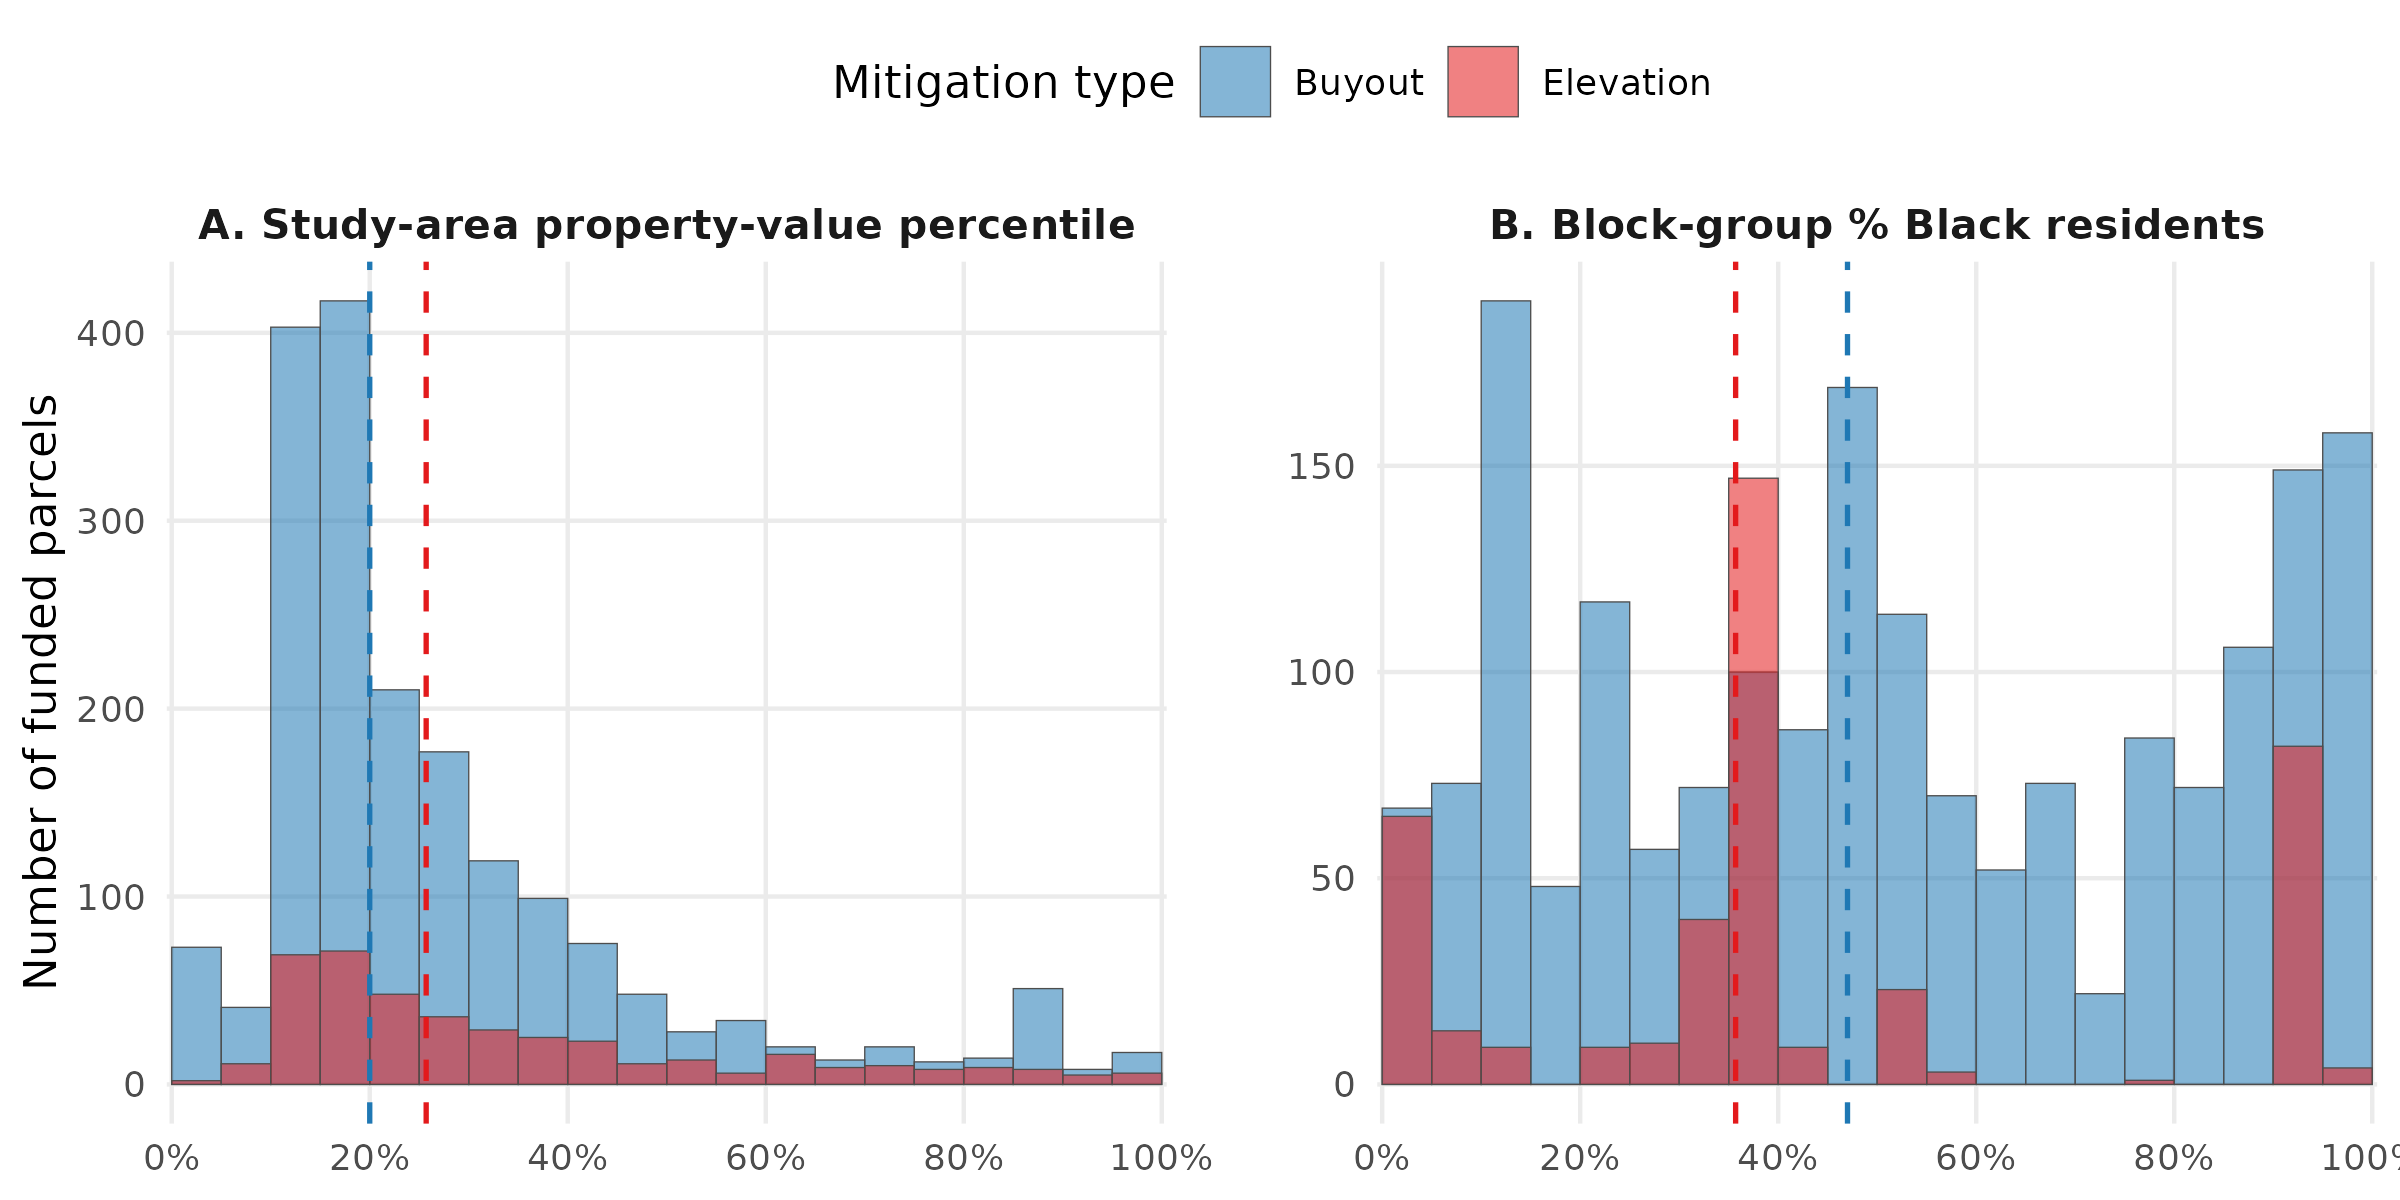
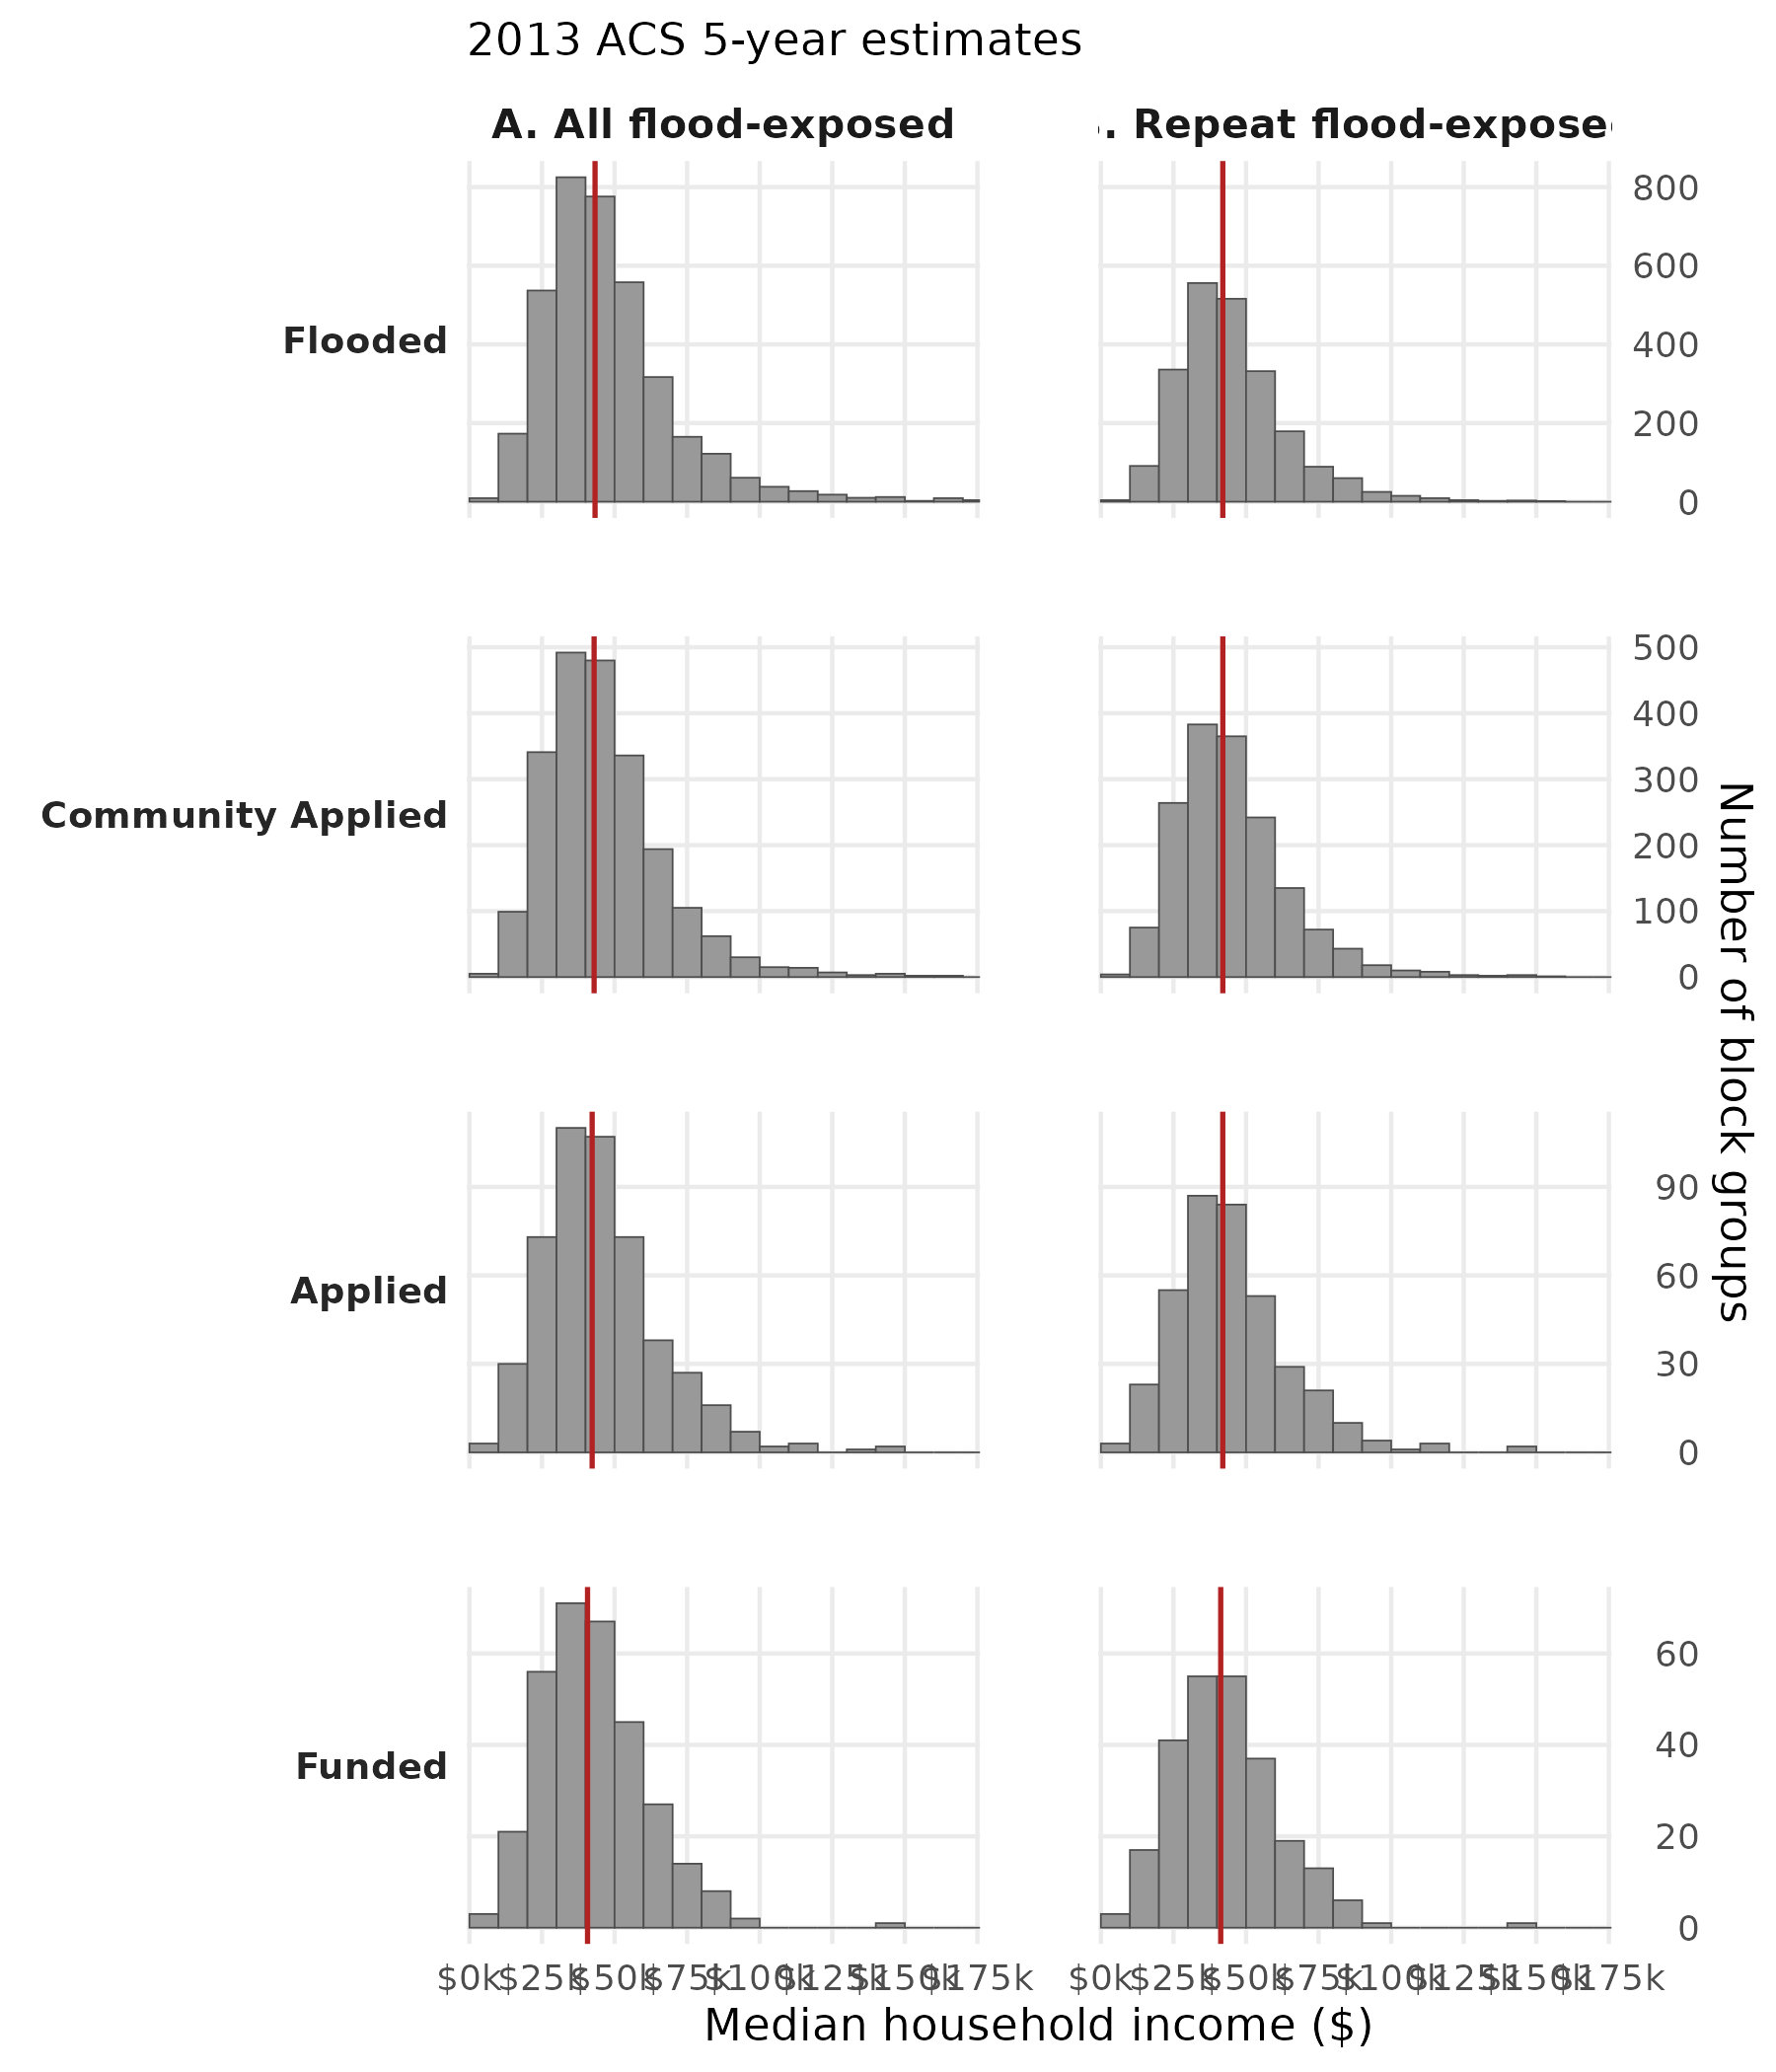
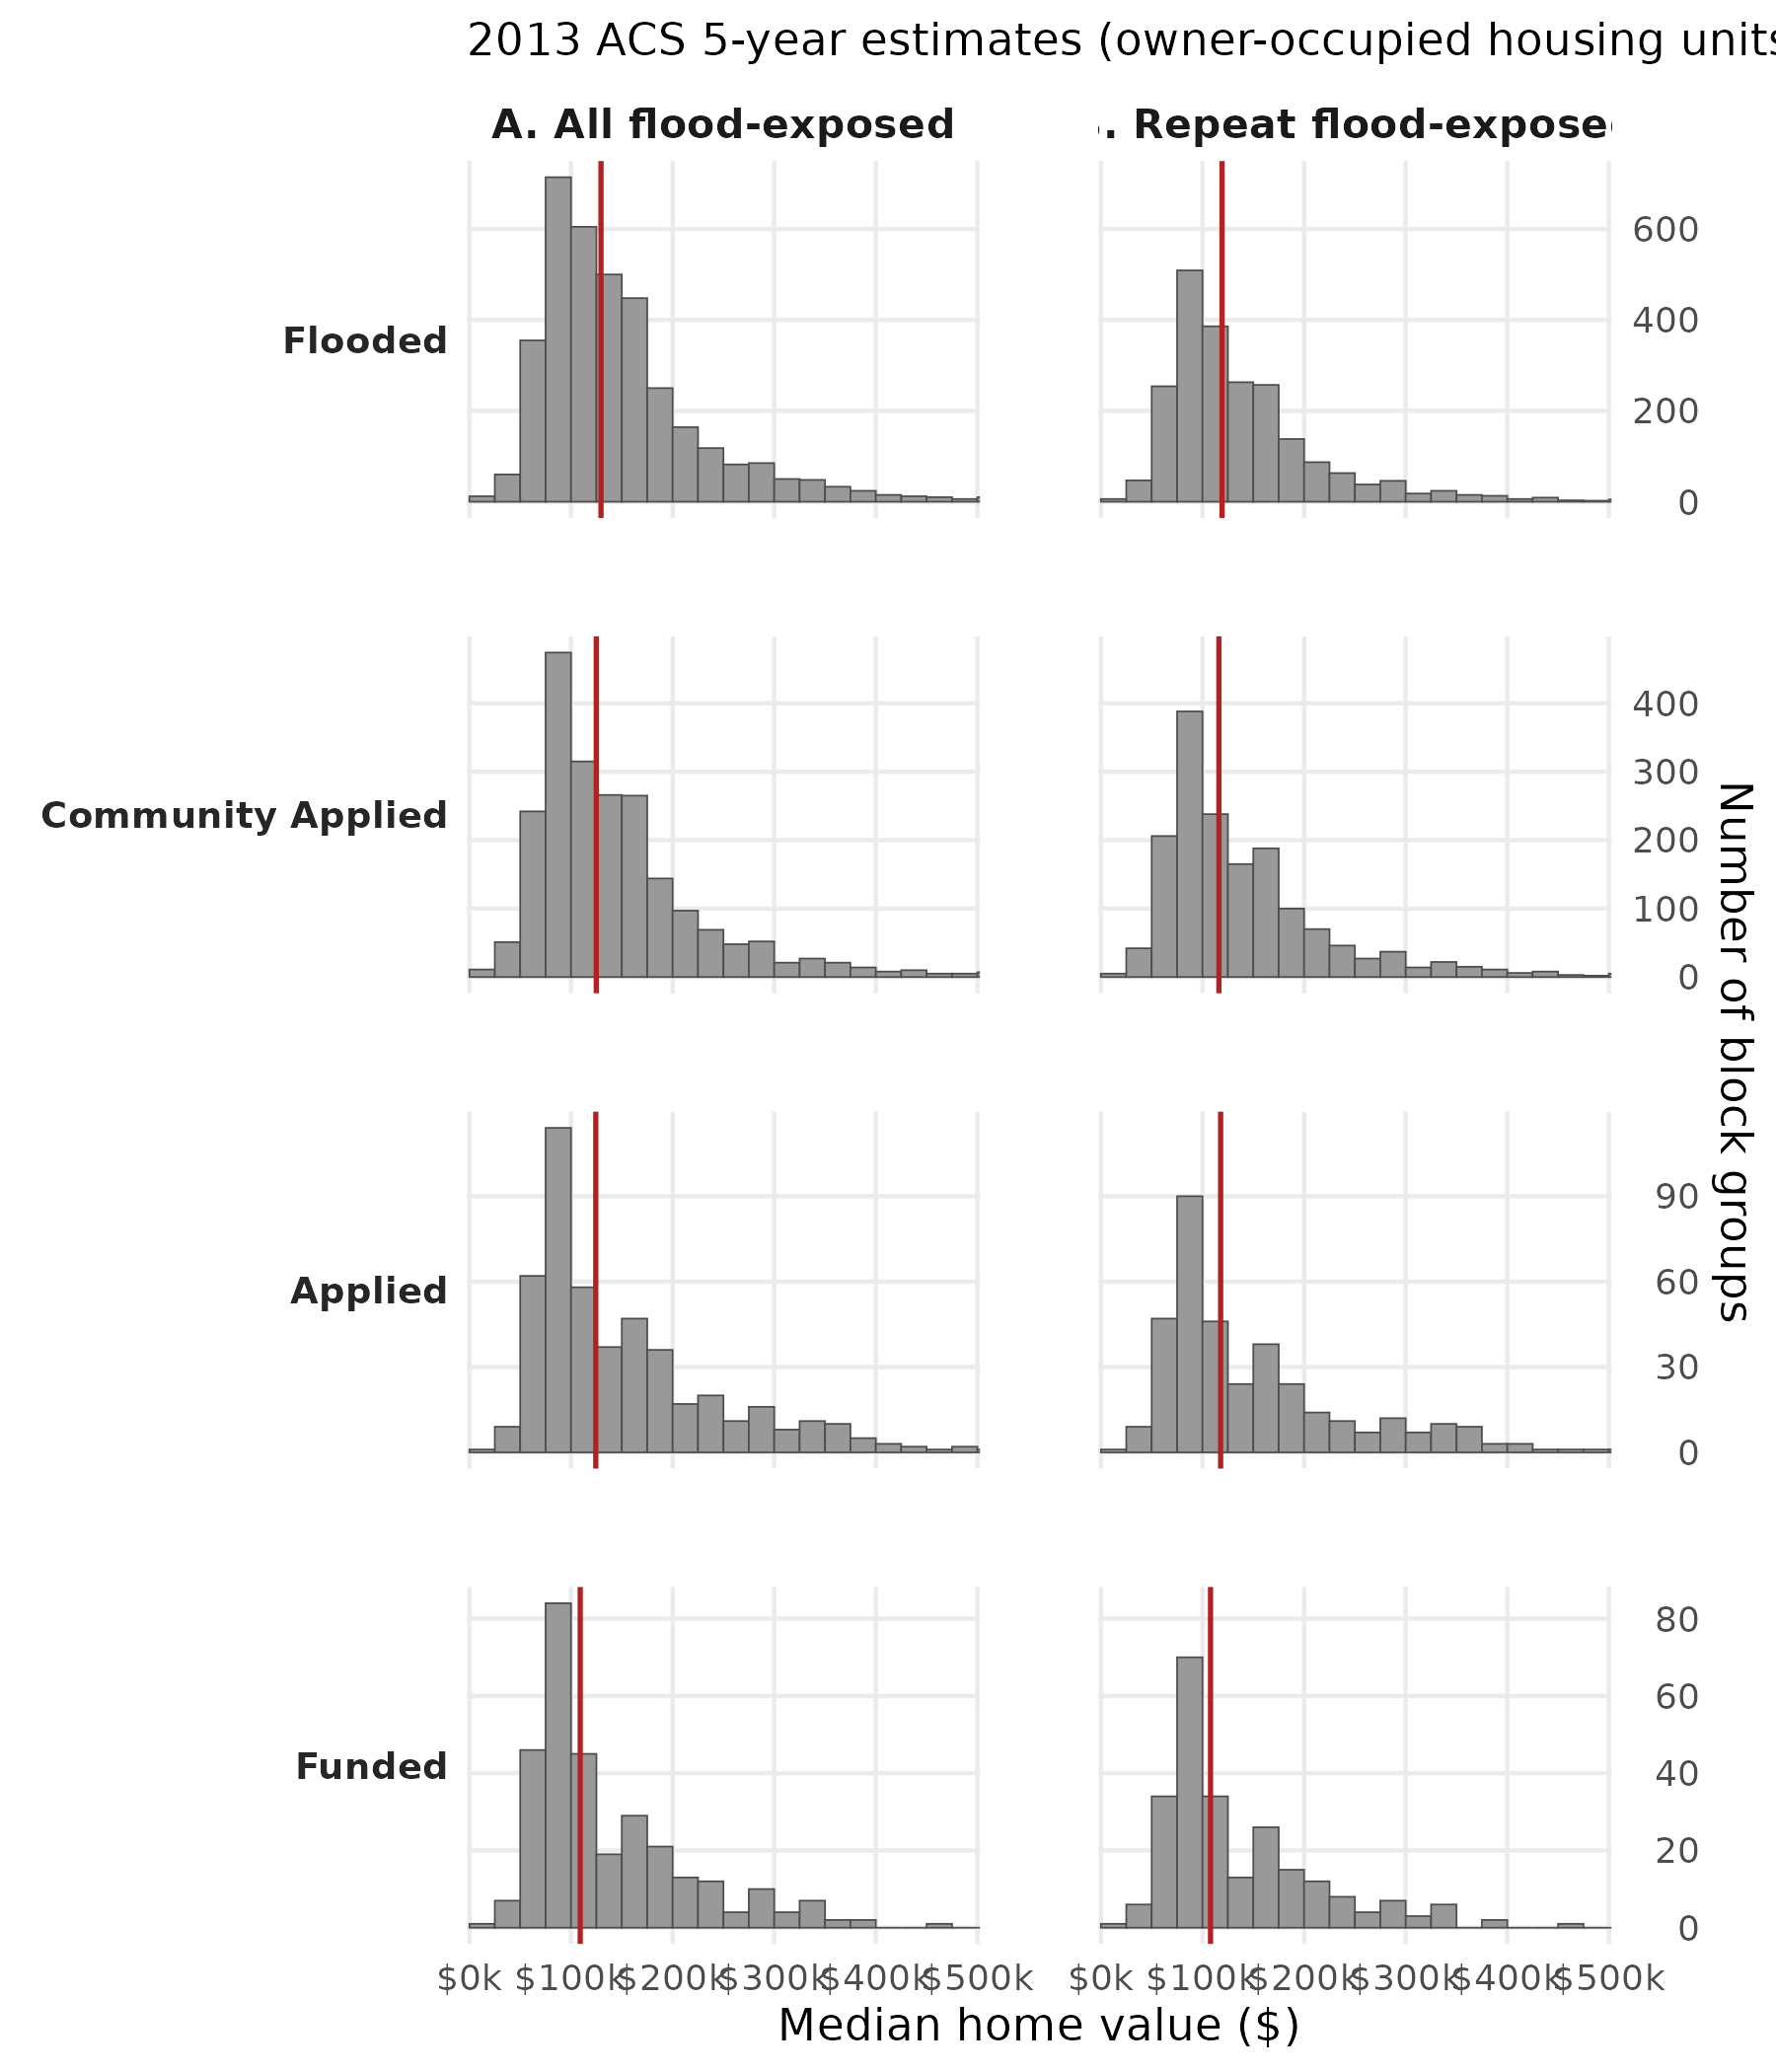
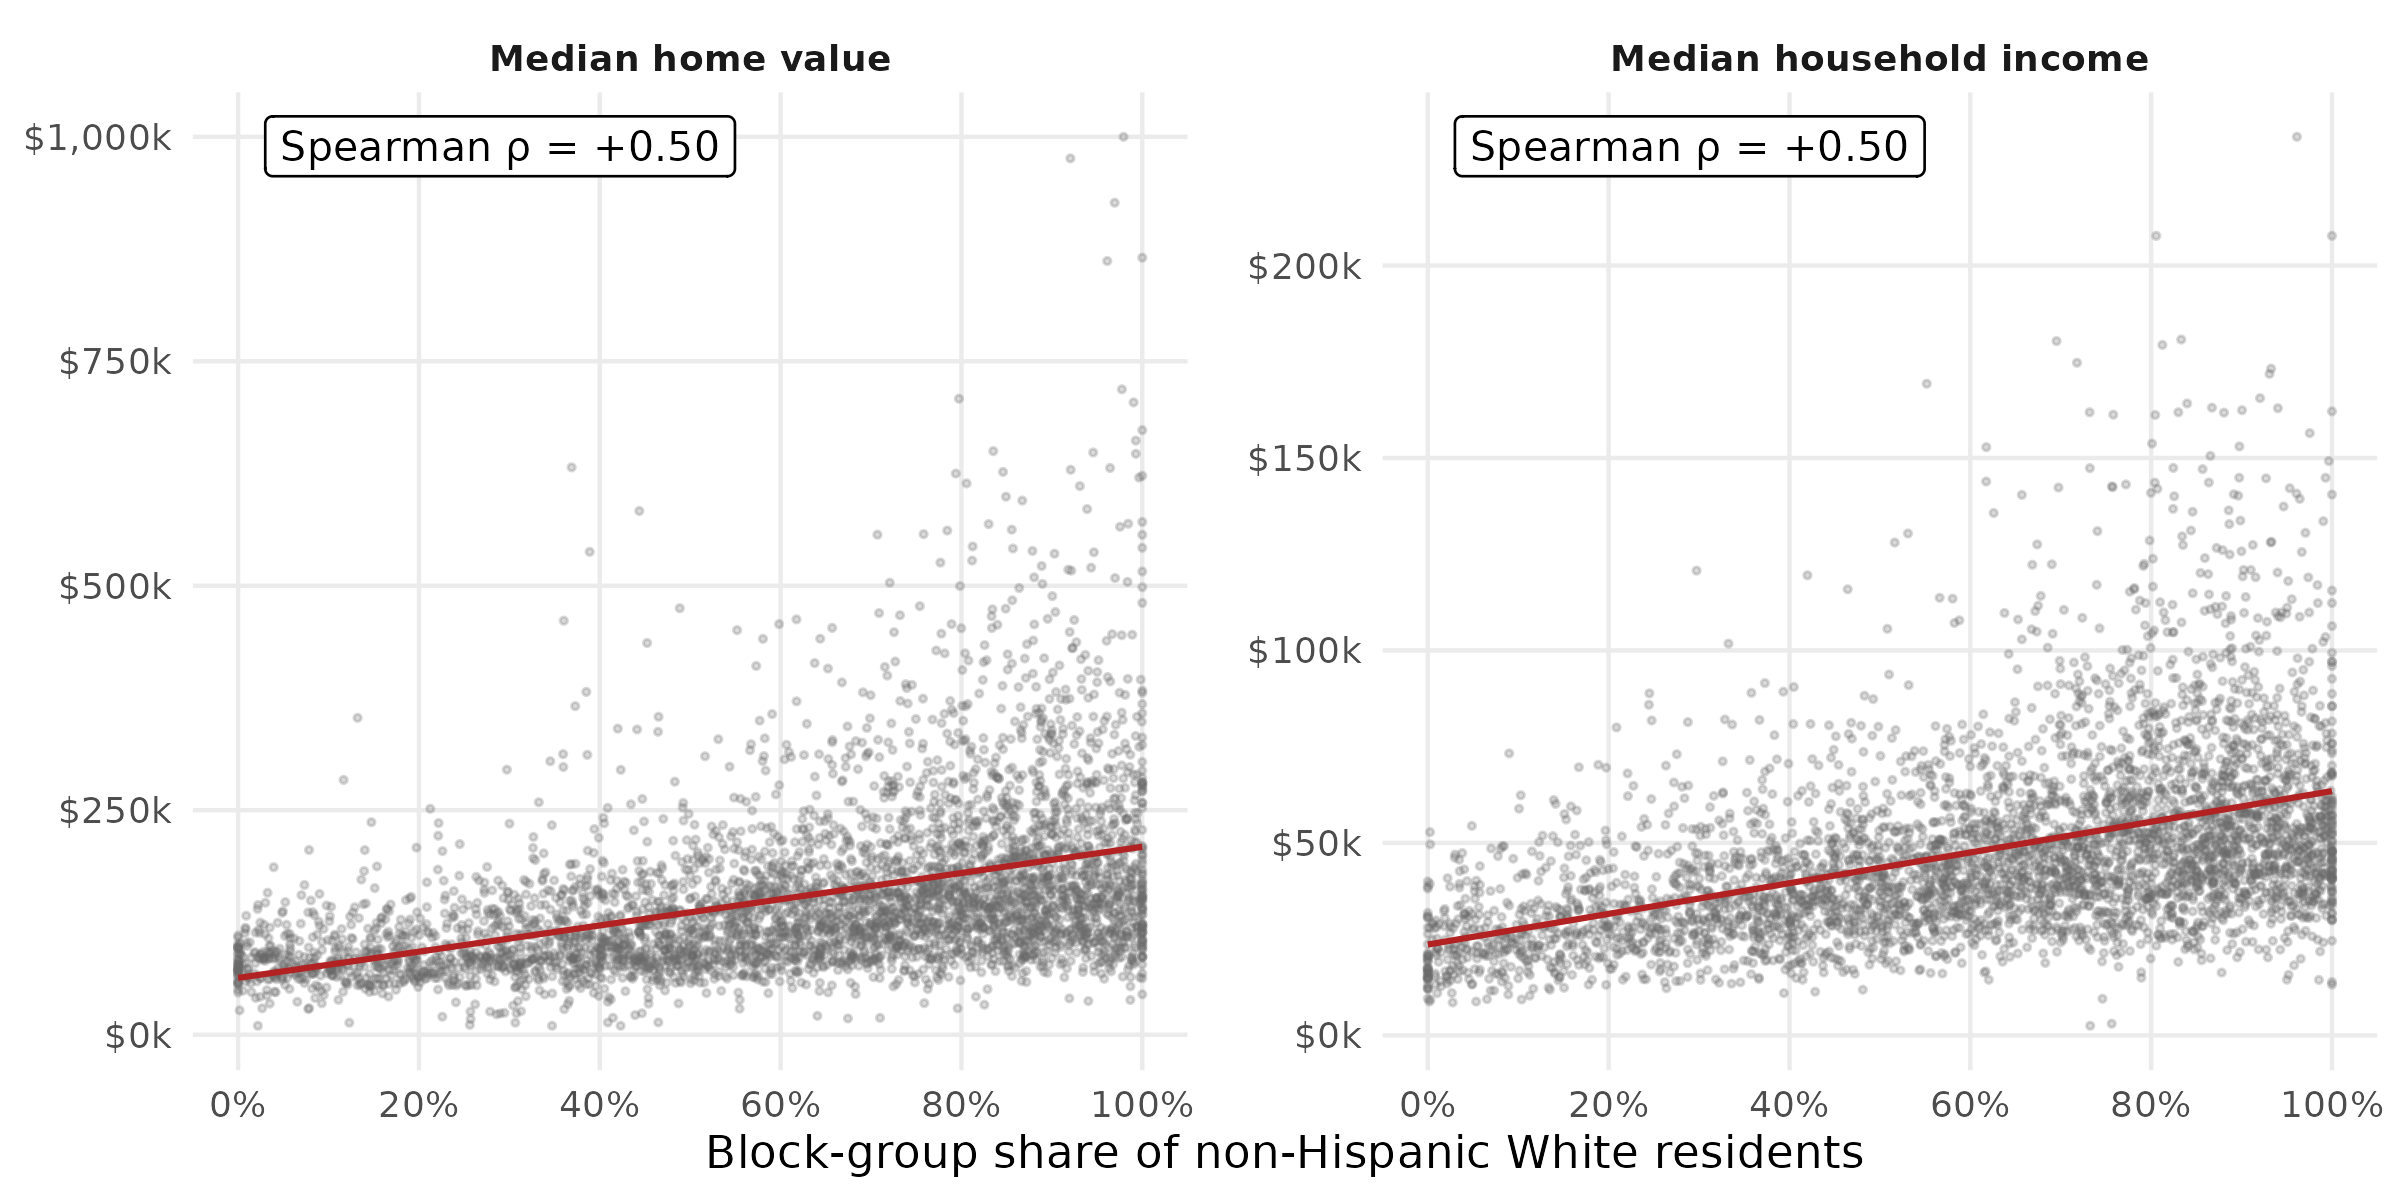